In [1]:
import pickle
import numpy as np
import os
import tqdm
import torch
import gc

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

from importlib import reload
from matplotlib import pyplot as plt

import matrix_approx_zeshel

matrix_approx_zeshel = reload(matrix_approx_zeshel)

!ls  | grep matrix_approx_zeshel

ModuleNotFoundError: No module named 'tensorflow'

In [4]:
!pip install tensorflow

Looking in indexes: https://pypi.yandex-team.ru/simple/
     |████████████████████████████████| 797.2 MB 41.3 MB/s eta 0:00:01     |████████████████▍               | 409.1 MB 53.9 MB/s eta 0:00:08     |█████████████████▍              | 433.1 MB 53.9 MB/s eta 0:00:07     |█████████████████████▌          | 536.2 MB 57.8 MB/s eta 0:00:05     |██████████████████████████      | 647.5 MB 52.9 MB/s eta 0:00:03
     |████████████████████████████████| 23.7 MB 4.3 MB/s eta 0:00:01
     |████████████████████████████████| 209.4 MB 60.0 MB/s eta 0:00:01
     |████████████████████████████████| 779.1 MB 33.8 MB/s eta 0:00:01    |██▉                             | 67.7 MB 50.7 MB/s eta 0:00:15     |██████████████▎                 | 348.4 MB 43.0 MB/s eta 0:00:11     |██████████████▉                 | 361.9 MB 43.0 MB/s eta 0:00:10     |██████████████████▎             | 444.0 MB 48.2 MB/s eta 0:00:07     |████████████████████▏           | 490.6 MB 32.4 MB/s eta 0:00:09     |████████████████████████▋    

     |████▎                           | 101.1 MB 216 kB/s eta 0:50:22                   | 296 kB 4.6 MB/s eta 0:02:46               | 9.0 MB 4.6 MB/s eta 0:02:44B/s eta 0:02:44                              | 9.6 MB 4.6 MB/s eta 0:02:44 | 9.9 MB 4.6 MB/s eta 0:02:444.6 MB/s eta 0:02:446 MB/s eta 0:02:44MB/s eta 0:02:44/s eta 0:02:44 eta 0:02:43ta 0:02:43[K     |▌                               | 11.8 MB 4.6 MB/s eta 0:02:43     |▌                               | 12.1 MB 4.6 MB/s eta 0:02:43[K     |▋                               | 14.5 MB 552 kB/s eta 0:22:23     |▋                               | 14.8 MB 552 kB/s eta 0:22:22   |▋                               | 15.1 MB 552 kB/s eta 0:22:22 |▋                               | 15.3 MB 552 kB/s eta 0:22:21[K     |▊                               | 16.9 MB 552 kB/s eta 0:22:18     |▊                               | 17.2 MB 552 kB/s eta 0:22:18   |▊                               | 17.5 MB 552 kB/s eta 0:22:17 |▊                               |

     |███████▋                        | 180.3 MB 210 kB/s eta 0:45:32     | 101.6 MB 216 kB/s eta 0:50:20 |████▎                           | 102.0 MB 216 kB/s eta 0:50:18██▎                           | 102.3 MB 216 kB/s eta 0:50:17�                           | 102.5 MB 216 kB/s eta 0:50:15                    | 102.7 MB 216 kB/s eta 0:50:14            | 103.0 MB 216 kB/s eta 0:50:13    | 103.2 MB 216 kB/s eta 0:50:123.5 MB 216 kB/s eta 0:50:1116 kB/s eta 0:50:10eta 0:50:09 |████▍                           | 104.4 MB 216 kB/s eta 0:50:07██▍                           | 104.6 MB 216 kB/s eta 0:50:05�                           | 104.9 MB 216 kB/s eta 0:50:04                    | 105.1 MB 216 kB/s eta 0:50:03            | 105.4 MB 216 kB/s eta 0:50:02    | 105.6 MB 216 kB/s eta 0:50:015.9 MB 216 kB/s eta 0:50:0016 kB/s eta 0:49:59eta 0:49:58 |████▌                           | 106.8 MB 191 kB/s eta 0:56:30██▌                           | 107.0 MB 191 kB/s eta 0:56:29�                          

     |████████�█▎                     | 242.7 MB 193 kB/s eta 0:44:0830B/s eta 0:45:29�█▊                        | 181.0 MB 210 kB/s eta 0:45:28210 kB/s eta 0:45:27                | 181.7 MB 210 kB/s eta 0:45:2545:24                     | 182.1 MB 210 kB/s eta 0:45:23ta 0:45:22�█▊                        | 183.1 MB 210 kB/s eta 0:45:19210 kB/s eta 0:45:17                | 183.7 MB 210 kB/s eta 0:45:15                     | 184.2 MB 210 kB/s eta 0:45:13��                        | 184.6 MB 210 kB/s eta 0:45:11B/s eta 0:45:10�█▉                        | 185.1 MB 210 kB/s eta 0:45:09210 kB/s eta 0:45:08                | 185.8 MB 282 kB/s eta 0:33:4033:39                     | 186.2 MB 282 kB/s eta 0:33:38ta 0:33:37��                        | 186.7 MB 282 kB/s eta 0:33:37B/s eta 0:33:36�██                        | 187.2 MB 282 kB/s eta 0:33:35282 kB/s eta 0:33:34                | 187.8 MB 282 kB/s eta 0:33:3333:32                     | 188.3 MB 282 kB/s eta 0:33:31ta 0:33:30��               

     |████████████                    | 284.5 MB 193 kB/s eta 0:40:29                   | 243.1 MB 193 kB/s eta 0:44:06    |██████████▎                     | 243.4 MB 193 kB/s eta 0:44:04██████████▎                     | 243.6 MB 193 kB/s eta 0:44:03�████████▎                     | 243.8 MB 193 kB/s eta 0:44:02��██████▍                     | 244.1 MB 193 kB/s eta 0:44:01█████▍                     | 244.3 MB 193 kB/s eta 0:44:00�███▍                     | 244.5 MB 193 kB/s eta 0:43:59��█▍                     | 244.7 MB 193 kB/s eta 0:43:58▍                     | 244.9 MB 193 kB/s eta 0:43:57                   | 245.1 MB 193 kB/s eta 0:43:55    |██████████▍                     | 245.4 MB 187 kB/s eta 0:45:21██████████▍                     | 245.6 MB 187 kB/s eta 0:45:19�████████▍                     | 245.8 MB 187 kB/s eta 0:45:18��██████▍                     | 246.1 MB 187 kB/s eta 0:45:17█████▍                     | 246.3 MB 187 kB/s eta 0:45:16�███▍                     | 246.5 MB 187 

...

     |████████████████████████████████| 670.2 MB 160 kB/s eta 0:00:0143�███████▋| 661.9 MB 162 kB/s eta 0:00:52��█████████████████████████▋| 662.0 MB 162 kB/s eta 0:00:51662.1 MB 162 kB/s eta 0:00:50███████▋| 662.4 MB 162 kB/s eta 0:00:49�█████████████████████████▋| 662.5 MB 162 kB/s eta 0:00:4862.7 MB 162 kB/s eta 0:00:47�████████████████▋| 662.8 MB 162 kB/s eta 0:00:465�███████▋| 663.1 MB 162 kB/s eta 0:00:44��█████████████████████████▊| 663.3 MB 162 kB/s eta 0:00:43663.4 MB 162 kB/s eta 0:00:42███████▊| 663.6 MB 157 kB/s eta 0:00:42�█████████████████████████▊| 663.8 MB 157 kB/s eta 0:00:4163.9 MB 157 kB/s eta 0:00:40�████████████████▊| 664.1 MB 157 kB/s eta 0:00:398�███████▊| 664.4 MB 157 kB/s eta 0:00:37��█████████████████████████▊| 664.5 MB 157 kB/s eta 0:00:36664.7 MB 157 kB/s eta 0:00:35     |███████████████████████████████▊| 664.7 MB 157 kB/s eta 0:00:35��█████▊| 664.9 MB 157 kB/s eta 0:00:34████████████████████████▊| 665.0 MB 157 kB/s eta 0:00:33 MB 157 kB/s eta 0:00:32███████

     |███████████████████             | 52.8 MB 162 kB/s eta 0:03:45                    | 296 kB 4.4 MB/s eta 0:00:21.4 MB/s eta 0:00:21▎                               | 860 kB 4.4 MB/s eta 0:00:21     | 1.1 MB 4.4 MB/s eta 0:00:2100:21                    | 1.7 MB 4.4 MB/s eta 0:00:214.4 MB/s eta 0:00:20|▉                               | 2.3 MB 4.4 MB/s eta 0:00:20      | 2.5 MB 4.4 MB/s eta 0:00:20:00:204 MB 4.4 MB/s eta 0:00:20                     | 3.6 MB 4.4 MB/s eta 0:00:202 MB 4.4 MB/s eta 0:00:20                     | 4.5 MB 4.4 MB/s eta 0:00:200 MB 4.4 MB/s eta 0:00:20                     | 5.3 MB 4.4 MB/s eta 0:00:208 MB 159 kB/s eta 0:08:45B/s eta 0:08:43 kB/s eta 0:08:4159 kB/s eta 0:08:40 159 kB/s eta 0:08:38MB 159 kB/s eta 0:08:364 MB 159 kB/s eta 0:08:357.7 MB 159 kB/s eta 0:08:33| 8.0 MB 159 kB/s eta 0:08:31298:28   | 8.8 MB 159 kB/s eta 0:08:260:08:24�▍                            | 9.3 MB 159 kB/s eta 0:08:23       | 9.6 MB 159 kB/s eta 0:08:21eta 0:08:1986 0:09:15�    

     |████████████████████████████████| 89.3 MB 160 kB/s eta 0:00:01███████████████████             | 53.1 MB 162 kB/s eta 0:03:43��█████████████▏            | 53.3 MB 162 kB/s eta 0:03:41███████████████████▏            | 53.5 MB 162 kB/s eta 0:03:40kB/s eta 0:03:36  | 54.0 MB 164 kB/s eta 0:03:35█▍            | 54.2 MB 164 kB/s eta 0:03:33�██████▌            | 54.4 MB 164 kB/s eta 0:03:32��███████████▋            | 54.6 MB 164 kB/s eta 0:03:31█████████████████▋            | 54.8 MB 164 kB/s eta 0:03:30kB/s eta 0:03:28kB/s eta 0:03:26  | 55.7 MB 164 kB/s eta 0:03:25██            | 55.8 MB 164 kB/s eta 0:03:23�███████            | 56.0 MB 164 kB/s eta 0:03:22████████████████████▏           | 56.2 MB 164 kB/s eta 0:03:21�           | 56.4 MB 164 kB/s eta 0:03:20��████████████████▎           | 56.6 MB 164 kB/s eta 0:03:19  | 56.7 MB 164 kB/s eta 0:03:18�█████████████▍           | 56.9 MB 164 kB/s eta 0:03:17B 166 kB/s eta 0:03:14██████████▌           | 57.3 MB 166 kB/s eta 0:03:13 eta 0:0

     |██▉                             | 59.1 MB 151 kB/s eta 1:07:03                    | 296 kB 4.3 MB/s eta 0:02:3570 kB 4.3 MB/s eta 0:02:35/s eta 0:02:3535                                | 1.7 MB 4.3 MB/s eta 0:02:35                    | 2.0 MB 4.3 MB/s eta 0:02:35        | 2.3 MB 4.3 MB/s eta 0:02:35:02:35               | 3.1 MB 4.3 MB/s eta 0:02:35B/s eta 0:02:35                              | 3.6 MB 4.3 MB/s eta 0:02:35 | 3.9 MB 4.3 MB/s eta 0:02:355                | 4.5 MB 4.3 MB/s eta 0:02:34MB/s eta 0:02:34                               | 5.0 MB 4.3 MB/s eta 0:02:34  | 5.3 MB 4.3 MB/s eta 0:02:34               | 5.9 MB 144 kB/s eta 1:16:25B/s eta 1:16:23                              | 6.4 MB 144 kB/s eta 1:16:21 | 6.7 MB 144 kB/s eta 1:16:197                | 7.3 MB 144 kB/s eta 1:16:15kB/s eta 1:16:14                               | 7.8 MB 144 kB/s eta 1:16:12  | 8.1 MB 144 kB/s eta 1:16:10               | 8.7 MB 144 kB/s eta 1:16:06B/s eta 1:16:04                           

     |███▉                            | 79.1 MB 155 kB/s eta 1:03:20^C▉                             | 59.6 MB 151 kB/s eta 1:06:591 kB/s eta 1:06:5760.2 MB 150 kB/s eta 1:07:23                          | 60.4 MB 150 kB/s eta 1:07:21:07:20    | 61.0 MB 150 kB/s eta 1:07:18█                             | 61.2 MB 150 kB/s eta 1:07:16 eta 1:07:14          | 61.7 MB 150 kB/s eta 1:07:13███                             | 62.0 MB 150 kB/s eta 1:07:110 kB/s eta 1:07:0962.6 MB 150 kB/s eta 1:07:07                          | 62.8 MB 150 kB/s eta 1:07:05:07:04    | 63.4 MB 150 kB/s eta 1:07:02█                             | 63.6 MB 150 kB/s eta 1:07:00 eta 1:06:59          | 64.1 MB 150 kB/s eta 1:06:57███                             | 64.4 MB 150 kB/s eta 1:06:550 kB/s eta 1:06:5365.0 MB 158 kB/s eta 1:03:27   |███▏                            | 65.2 MB 158 kB/s eta 1:03:26   |███▏                            | 65.5 MB 158 kB/s eta 1:03:24   |███▏                            | 65.8 MB 158 kB/s eta 1

# Open Data loader & context

In [2]:
def load_ment_to_ent_scores(directory = "yugioh", shuffle_rows = 0, full = True):
    data = list()

    for file in os.listdir(directory):
        path = f"{directory}/{file}"
        print(f"Loading file {path}")
        with open(path, "rb") as f:
            data.append(
                pickle.load(f)
            )
    data = sorted(data, key = lambda x: x["arg_dict"]["n_ment_start"])

    for i in range(len(data) - 1):
        if full:
            assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] == data[i + 1]["arg_dict"]["n_ment_start"]
        else:
            assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] <= data[i + 1]["arg_dict"]["n_ment_start"]
        
    ment_to_ent_scores = list(map(lambda x: x["ment_to_ent_scores"], data))
    ment_to_ent_scores = np.vstack(ment_to_ent_scores)
    print("Loaded shape = ", ment_to_ent_scores.shape)
    
    if shuffle_rows:
        print(f"Shuffling... (seed = {shuffle_rows})")
        np.random.seed(shuffle_rows)
        np.random.shuffle(ment_to_ent_scores)
    
    return ment_to_ent_scores

In [3]:
from sklearn.cluster import KMeans

def from_labels(X, labels):
    K = list()
    for i in range(100):
        sl_i = np.arange(X.shape[0])[labels == i]
        sl = X[labels == i]
        
        if len(sl_i) == 0:
            # bug-mode
            while True:
                chosen = np.random.choice(np.arange(X.shape[0])[labels < i], size=1)[0]
                if chosen not in K:
                    K.append(chosen)
                    break
            continue
            
        center = sl.mean(axis=0).reshape(1, -1)
        best = euclidean_distances(sl, center).argmin()
        K.append(sl_i[best])
        assert labels[K[-1]] == i
    return K

class EvalContextRelevs:
    def __init__(self, relevs, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
        self.relevs = np.array(relevs)
        self.reqs_count = self.relevs.shape[0]
        self.games_count = self.relevs.shape[1]
        
        self.key_size = key_size
        self.key_games = (
            np.random.choice(np.arange(self.games_count), key_size, replace=False)
            if key_games is None else
            key_games
        )
        np.random.seed(seed)
        #np.random.shuffle(self.requests)

        self.try_det_attempts(det_attempts)
        self.train_split = int(self.reqs_count * train_size)

        assert key_size + 1 < self.train_split


        self.key_relevs = self.relevs[:key_size]
        self.train_relevs = self.relevs[key_size + 1: self.train_split]
        self.test_relevs = self.relevs[self.train_split:]

        self.slices = ["key", "train", "test"]
        print(len(self.key_relevs), len(self.train_relevs), len(self.test_relevs))

    def get_top_games(self):
        return self.relevs.mean(axis=0).argsort()[:100]

    def set_top_games_as_key(self):
        self.key_games = self.get_top_games()
        return self

    def get_kmeans_games(self, all_from_labels=True):
        X = self.get_relevs("train").T

        k_func = (
            (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
            if not all_from_labels else
            (lambda C : from_labels(X, C.labels_))
        )
        K_KMeans = k_func(
            KMeans(n_clusters=self.key_size, random_state=0).fit(X)  #, n_init="auto").fit(X)
        )
        
        return K_KMeans
    
    def set_kmeans_games_as_key(self, *args, **kwargs):
        self.key_games = self.get_kmeans_games(*args, **kwargs)
        return self
    

    def try_det_attempts(self, det_attempts):
        def get_det(r):
            kr = r[:self.key_size, self.key_games] - r.mean()
            return np.abs(np.linalg.det(kr))

        best_i_array = np.arange(len(self.relevs))

        for i in range(det_attempts):

            r_i_array = np.arange(len(self.relevs))
            np.random.shuffle(r_i_array)

            n, o = get_det(self.relevs[r_i_array, :]), get_det(self.relevs[best_i_array, :])
            
            # print(f"try update key_reqs ({o} vs {n}...")
            if n > o:
                best_i_array = r_i_array
                print(f"updated det ({i}, {o} -> {n})")

        print("Best det = ", get_det(self.relevs[best_i_array, :]))

        self.relevs = self.relevs[best_i_array, :]
        print("Current de = ", get_det(self.relevs))
        
    def get_relevs(self, t = "train"):
        if t == "train":
            return self.train_relevs
        elif t == "key":
            return self.key_relevs
        elif t == "test":
            return self.test_relevs
        else:
            assert False
            
    def get_requests(self, t = "train"):
        if t == "train":
            return self.train_reqs
        elif t == "key":
            return self.key_reqs
        elif t == "test":
            return self.test_reqs
        else:
            assert False

# Games Data loader & context

In [4]:
import collections
import pickle
import numpy as np
import tqdm
import os
import gc

import matplotlib.pyplot as plt


def load(limit, raw_path = "stand/log.local.logtime2.txt", path = "log.local.logtime2.bin", key_games = None, seed = 17, det_attempts = 0):
    readvector = lambda s : np.array(list(map(float, s.strip()[1:-2].split(","))))
    requests = list()
    docembs = collections.defaultdict(dict)

    if os.path.isfile(path):
        with open(path, "rb") as f:
            flimit, frequests, fdocembs = pickle.load(f)
            if flimit == limit:
                requests, docembs = frequests, fdocembs
            else:
                print(f"WARN: buffered limit is different, {flimit} != {limit}, reloading...")

    if not requests:
        with open(raw_path) as f:
            req = list()
            reqid = None
            models = list()
            prevreqmodel = None
            reqmodel = dict()
            prevmodelid = -1
            bannermodelid = -1
            for i, line in tqdm.tqdm_notebook(enumerate(f)):
                if line.startswith("Model = 6;"):
                    prevreqmodel = reqmodel
                    reqmodel = dict()

                if line.startswith("Model = "):
                    spl = line.split(" ")
                    prevmodelid = int(spl[2][:-1])
                    bannermodelid = max(bannermodelid , prevmodelid)
                    reqmodel[prevmodelid] = readvector(spl[3])
                elif line.startswith("dbid"):
                    spl = line.split(" ")
                    dbid = int(spl[1][:-1])
                    docembs[bannermodelid][dbid] = readvector(spl[2])
                elif line.startswith("seed"):
                    if len(requests) >= limit:
                        break
                    if req:
                        requests.append((reqid, prevreqmodel, sorted(req)))
                        req = list()
                    reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
                else:
                    req.append(
                        (int(line.split()[0]), float(line.split()[1]))
                    )
        
        with open(path, "wb") as f:
            pickle.dump((limit, requests, docembs), f)

    games_count = len(requests[0][2])
    assert games_count == 16514
    requests = [r for r in requests if len(r[2]) == games_count]
    
    print([(i, len(docembs[i].keys())) for i in docembs])  # should be equal
    docblocks = {
        mid : np.array([x[1] for x in sorted(list(docembs[mid].items()))])
        for mid in docembs
    }
    
    class EvalContext:
        def __init__(self, games_count = games_count, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
            self.games_count = games_count
            
            self.key_size = key_size
            self.key_games = (
                np.random.choice(np.arange(games_count), key_size, replace=False)
                if key_games is None else
                key_games
            )

            self.requests = requests
            np.random.seed(seed)
            np.random.shuffle(self.requests)
            
            self.try_det_attempts(det_attempts)

            self.key_reqs = self.requests[:key_size + 1]
            self.key_reqs_idx = np.arange(key_size + 1)

            self.train_split = int(len(self.requests) * train_size)

            assert key_size + 1 < self.train_split

            self.train_reqs = self.requests[key_size + 1: self.train_split]
            self.test_reqs = self.requests[self.train_split:]

            self.slices = ["key", "train", "test"]
            print(len(self.key_reqs), len(self.train_reqs), len(self.test_reqs))

            self.docblocks = docblocks
            self.relevs = dict()
            
        def get_top_games(self):
            if not hasattr(self, "top_games"):
                embed_games = np.array([
                    np.array([r[2][g_i][1] for r in self.get_requests("train")])
                    for g_i in range(self.games_count)
                ])

                self.embed_games_mean = embed_games.mean(axis=1)
                self.top_games_all = (-self.embed_games_mean).argsort()
                self.top_games = self.top_games_all[:len(self.key_games)]

            return self.top_games
        
        def set_top_games_as_key(self):
            self.key_games = self.get_top_games()
            return self
        
        def get_kmeans_games(self, all_from_labels=True):
            X = self.get_relevs("train").T

            k_func = (
                (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
                if not all_from_labels else
                (lambda C : from_labels(X, C.labels_))
            )
            K_KMeans = k_func(
                KMeans(n_clusters=self.key_size, random_state=0).fit(X)  #, n_init="auto").fit(X)
            )

            return K_KMeans

        def set_kmeans_games_as_key(self, *args, **kwargs):
            self.key_games = self.get_kmeans_games(*args, **kwargs)
            return self

        def try_det_attempts(self, det_attempts, model_id = 6):
            def get_det(r, r_i_array):
                kr = np.array([
                    r[r_i][1][model_id]
                    for r_i in r_i_array[:100]
                ])
                return np.abs(np.linalg.det(kr[:kr.shape[1], :]))

            best_i_array = np.arange(len(self.requests))

            for _ in range(det_attempts):
                # print("try update key_reqs...")
                
                r_i_array = np.arange(len(self.requests))
                np.random.shuffle(r_i_array)
                
                n, o = get_det(self.requests, r_i_array), get_det(self.requests, best_i_array)
                # print(n, o)
                if n > o:
                    best_i_array = r_i_array
                    # print("updated!")

            print("Best det = ", get_det(self.requests, best_i_array))
            
            new_requests = [
                self.requests[i]
                for i in best_i_array
            ]
            
            del self.requests
            gc.collect()

            self.requests = new_requests
            print(get_det(self.requests, np.arange(len(self.requests))))

        def get_relevs(self, t = "train"):
            if t not in self.relevs:
                self.relevs[t] = np.array([
                    np.array([g_i[1] for g_i in r[2]])
                    for r in self.get_requests(t)
                ])
                
            return self.relevs[t]

        def get_requests(self, t = "train"):
            if t == "train":
                return self.train_reqs
            elif t == "key":
                return self.key_reqs
            elif t == "test":
                return self.test_reqs
            else:
                assert False

    return EvalContext(key_games = key_games, seed = seed, det_attempts = det_attempts)

# Models

In [5]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        self.trus_top = dict()
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):    
        recs = self.recommend(t)
        
        if isinstance(recs, list):
            recs = np.array(recs)
        
        mse = np.mean((recs - self.get_user_scores(t)) ** 2)
        
        if isinstance(recs, tf.Tensor):
            recs = tf.argsort(-recs, axis=1)[:, :topsize].numpy()
        else:
            recs = np.argsort(-recs, axis=1)[:, :topsize]
        
        if (t, topsize) not in self.trus_top:
            trus = self.get_user_scores(t)
            trus = np.argsort(-trus, axis=1)[:, :topsize]
            self.trus_top[(t, topsize)] = trus
            
        trus = self.trus_top[(t, topsize)]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [6]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "matrix_l2": 0,
    "dssm_l2": 0,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_matrix": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
    "activation": "relu",
    "score_verbose": 0,
    "trainable_items": False,
    "use_keys_in_train": False,
    "Winit": "glorot0.01",
    "Wfreeze": False,
    "TEinit": "legacy",
    "normalize_embs": True
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(fit_kwargs)
        self.fit_kwargs = p
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[i] for i in sorted(ctx.key_games)])
                    for r_i in ctx.get_relevs(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[g_i] for r in ctx.get_relevs("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        
        if self.fit_kwargs["trainable_items"]:
            if self.fit_kwargs["TEinit"] == "legacy":
                value = self.embed_games
            elif self.fit_kwargs["TEinit"] == "anncur":
                key_cols_idx = np.array(sorted(ctx.key_games))
                value = (
                    np.linalg.pinv(ctx.get_relevs("train")[:, key_cols_idx])
                    @ ctx.get_relevs("train")
                ).T
                print(type(value))
            else:
                assert False, "unknown TEinit: " + str(self.fit_kwargs["TEinit"])
                
            self.trainable_games = tf.Variable(
                tf.convert_to_tensor(value, dtype=tf.float32),
                trainable=True
            )
        else:
            if self.fit_kwargs["TEinit"] == "anncur":
                key_cols_idx = np.array(sorted(ctx.key_games))
                self.embed_games = (
                    np.linalg.pinv(ctx.get_relevs("train")[:, key_cols_idx])
                    @ ctx.get_relevs("train")
                ).T
                print("ANNCur init")
            
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = ctx.get_relevs("key")
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        if self.fit_kwargs["normalize_embs"]:
            return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        else:
            return self.embed_users[t]
    
    def get_game_embs(self):
        if not self.fit_kwargs["trainable_items"]:
            if self.fit_kwargs["normalize_embs"]:
                return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
            else:
                return self.embed_games 
        else:
            return self.trainable_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.p = p
        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_matrix = p["train_matrix"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        if p["use_keys_in_train"]:
            train_user_scores = np.vstack([
                self.get_user_scores("key"),
                self.get_user_scores("train")
            ])
            train_user_embs = np.vstack([
                self.get_user_embs("key"),
                self.get_user_embs("train")
            ])
        else:
            train_user_scores = self.get_user_scores("train")
            train_user_embs = self.get_user_embs("train")

        game_embs = self.get_game_embs()
        
        
        
        if self.p["Winit"] == "glorot0.01":
            initializer = tf.keras.initializers.GlorotUniform()
            values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
            values = values / 100.  
        elif self.p["Winit"] == "glorot":
            initializer = tf.keras.initializers.GlorotUniform()
            values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        elif self.p["Winit"] == "eye":
            values = np.eye(train_user_embs.shape[1], game_embs.shape[1])
        else:
            assert False, "init is not known:" + str(self.p["init"])
            
        self.W = tf.Variable(values, trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = (
                            game_embs[game_slice]
                            if isinstance(game_embs, np.ndarray) else
                            tf.gather(game_embs, game_slice)
                        )
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = 0
                    
                    if self.train_matrix:
                        logits += train_user_embs_ @ self.W @ tf.transpose(game_embs_)

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_signed":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    sf = tf.nn.softmax(logits, axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        sf,
                        -sf
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_sum(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                elif self.loss == "KL100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    mask = np.argsort(-scores, axis=1) < 100
                    v = tf.keras.losses.KLDivergence()((scores.T >= qs.T).T, logits)
                else:
                    assert False
                    
                if self.p["c"]:
                    v += tf.reduce_mean(self.W * self.W) * p["c"]
                    
                if self.p["dssm_l2"]:
                    for weights_ in [self.u_dssm.weights, self.g_dssm.weights]:
                        for weight_ in weights_:
                            v += tf.reduce_sum(weight_ * weight_) * self.p["dssm_l2"]
                
                if self.p["matrix_l2"]:
                    v += tf.reduce_sum(self.W * self.W) * self.p["matrix_l2"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            if self.train_matrix and (not self.p["Wfreeze"]):
                weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
            
            if self.p["trainable_items"]:
                weights += [self.trainable_games]
                
                
            opt.minimize(loss, weights)
            
            if p["score_verbose"] and (i % p["score_verbose"] == 0):
                print(f"\n=== Iteration {i} ===")
                for sl in self.ctx.slices:
                    print(f"slice = {sl}, score = {self.get_score(sl)}")
        print("last loss = ", loss())

    def recommend(self, t):
        logits = 0
                    
        if self.train_matrix:
            logits += self.get_user_embs(t) @ self.W @ tf.transpose(self.get_game_embs())

        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [7]:
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [8]:
class AnnCUR(Popular):
    def __init__(self, ctx, oracle=False, key_games=None, name=None):
        super().__init__(ctx)
        self.oracle = oracle
        self.ctx = ctx
        self.name = name

        self.key_cols_idx = np.array(sorted(ctx.key_games if key_games is None else key_games))
        rows_idx = np.arange(ctx.get_relevs("train").shape[0])
        
        self.cur = matrix_approx_zeshel.CURApprox(
            rows=torch.from_numpy(ctx.get_relevs("train")),
            cols=torch.from_numpy(ctx.get_relevs("train")[:, self.key_cols_idx]),
            row_idxs=rows_idx,
            col_idxs=self.key_cols_idx,
            approx_preference="rows",
            A=(torch.from_numpy(ctx.get_relevs("train")) if oracle else None)
        )        
        
    def __repr__(self):
        if self.name is None:
            return f"AnnCur({id(self)})"
        else:
            return f"AnnCur({self.name} - {id(self)})"
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        key_relevs = torch.from_numpy(self.ctx.get_relevs(t)[:, self.key_cols_idx])
        return self.cur.get_complete_row(key_relevs)
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

# Evals

In [9]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

def from_labels(X, labels):
    K = list()
    for i in range(100):
        sl_i = np.arange(X.shape[0])[labels == i]
        sl = X[labels == i]
        
        if len(sl_i) == 0:
            # bug-mode
            while True:
                chosen = np.random.choice(np.arange(X.shape[0])[labels < i], size=1)[0]
                if chosen not in K:
                    K.append(chosen)
                    break
            continue
            
        center = sl.mean(axis=0).reshape(1, -1)
        best = euclidean_distances(sl, center).argmin()
        K.append(sl_i[best])
        assert labels[K[-1]] == i
    return K

def K_by_min(X):
    center = X.mean(axis=0)
    K = [euclidean_distances(X, center.reshape(1, -1)).argmax()]

    while len(K) < 100:
        K.append(euclidean_distances(X, X[K]).min(axis=1).argmax())
    return K


def eval_clustering(ctx, all_from_labels=False):
    X = ctx.get_relevs("train").T
    from sklearn.cluster import KMeans
    
    k_func = (
        (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
        if not all_from_labels else
        (lambda C : from_labels(X, C.labels_))
    )
    
    K_KMeans = k_func(
        KMeans(n_clusters=100, random_state=0).fit(X)  #, n_init="auto").fit(X)
    )


    from sklearn.cluster import BisectingKMeans
    K_BisectingKMeans = k_func(
        BisectingKMeans(n_clusters=100, random_state=0).fit(X)
    )


    from sklearn.cluster import MiniBatchKMeans
    K_MiniBatchKMeans = from_labels(
        X,
        MiniBatchKMeans(n_clusters=100, random_state=0).fit(X).labels_
    )

    from sklearn.cluster import AgglomerativeClustering
    K_AgglomerativeClustering = from_labels(
        X,
        AgglomerativeClustering(n_clusters=100).fit(X).labels_
    )

    from sklearn.cluster import SpectralCoclustering
    K_SpectralCoclustering = from_labels(
        X,
        SpectralCoclustering(n_clusters=100, random_state=0).fit(X).row_labels_
    )

    from sklearn.cluster import SpectralBiclustering
    K_SpectralBiclustering = from_labels(
        X,
        SpectralBiclustering(n_clusters=100, random_state=0).fit(X).row_labels_
    )

    from sklearn.cluster import SpectralClustering
    K_SpectralClusteringNN = from_labels(
        X,
        SpectralClustering(n_clusters=100, random_state=0, affinity="nearest_neighbors", n_jobs=-1).fit(X).labels_
    )

    K_ByMin = K_by_min(X)

    ev([
        Popular(ctx),
        AnnCUR(ctx),
        AnnCUR(ctx, key_games=np.arange(100), name="key_games=np.arange(100)"),
        AnnCUR(ctx, key_games=np.random.choice(np.arange(X.shape[0]), size=100, replace=False), name="random"),
        AnnCUR(ctx, key_games=K_KMeans, name="K_KMeans"),
        AnnCUR(ctx, key_games=K_BisectingKMeans, name="K_BisectingKMeans"),
        AnnCUR(ctx, key_games=K_MiniBatchKMeans, name="K_MiniBatchKMeans"),
        AnnCUR(ctx, key_games=K_AgglomerativeClustering, name="K_AgglomerativeClustering"),
        AnnCUR(ctx, key_games=K_SpectralCoclustering, name="K_SpectralCoclustering"),
        AnnCUR(ctx, key_games=K_SpectralBiclustering, name="K_SpectralBiclustering"),
        AnnCUR(ctx, key_games=K_SpectralClusteringNN, name="K_SpectralClusteringNN"),
        AnnCUR(ctx, key_games=K_ByMin, name="K_ByMin"),
    ])

In [10]:
DATASETS = ["yugioh", "pro_wrestling", "star_trek", "doctor_who", "military"]

# support items choice

In [11]:
# setup:
# 1000 items, 1000 + 1000 queries
recall_k = 5
n_runs = 10
n_items_per_run = 1000
test_item_cnt = 100
item_cnt_range = list(range(5, 101, 5))
assert test_item_cnt in item_cnt_range

In [12]:
from collections import defaultdict
from itertools import combinations

from matplotlib import pyplot as plt
import numpy as np
import os
from sklearn.metrics import top_k_accuracy_score
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu, ttest_rel

In [13]:
#with open("collections_10000_items/test.npy", "rb") as fin:
#    all_test = np.load(fin)
#with open("collections_10000_items/train.npy", "rb") as fin:
#    all_train = np.load(fin)

#assert all_train.shape[0] == n_runs * n_items_per_run
#assert all_test.shape[0] == n_runs * n_items_per_run


In [14]:
def eval_items(items, train, test):
    item_embeds = train.dot(np.linalg.pinv(train[items]))
    approx_test_rel = item_embeds.dot(test[items])
    approx_train_rel = item_embeds.dot(train[items])
    best_items = np.argsort(test, axis=0)[-1]
    recall = top_k_accuracy_score(best_items, approx_test_rel.T, k=recall_k, labels=np.arange(train.shape[0]))
    test_mse = np.mean((test - approx_test_rel) ** 2)
    train_mse = np.mean((train - approx_train_rel) ** 2)
    return recall, test_mse, train_mse

def get_rnd_items(n_items, train):
    return np.random.choice(train.shape[0], n_items, replace=False)

def get_kmeans_items(n_items, train):
    kmeans = KMeans(n_clusters=n_items, n_init="auto").fit(train)
    items = []
    for center in kmeans.cluster_centers_:
        distances = ((train - center) ** 2).sum(axis=1)
        assert distances.shape == (train.shape[0],)
        for item_id in np.argsort(distances):
            if item_id not in items:
                items.append(item_id)
                break
    return np.array(items, dtype=np.int64)

greedy_items = []
def get_greedy(n_items, train, lazy=True):
    global greedy_items
    if not lazy:
        greedy_items = []
    if len(greedy_items) >= n_items:
        return np.array(greedy_items[:n_items], dtype=np.int64)
    
    gram = train.dot(train.T)
    gram /= gram.mean()
    items = []
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        scores = (gram ** 2).sum(axis=1)
        assert np.allclose(scores[~remaining_items], np.zeros_like(scores[~remaining_items])), (
            t, scores[~remaining_items]
        )
        scores[remaining_items] /= gram[remaining_items, remaining_items]
        if max(scores) < 1e-9:
            break
        new_item = scores.argmax()
        assert remaining_items[new_item]
        coefs = gram[new_item] / np.sqrt(gram[new_item, new_item])
        diff = coefs.reshape(-1, 1).dot(coefs.reshape(1, -1))
        gram -= diff
        assert np.allclose(gram[new_item], np.zeros_like(gram[new_item]), atol=1e-6), (
            t, gram[new_item].std()
        )
        items.append(new_item)
        remaining_items[new_item] = False
    assert len(items) == n_items
    greedy_items.clear()
    greedy_items.extend(items)
    return np.array(items, dtype=np.int64)


### fast-a

In [15]:
def coitem_algorithm(n_support, candidate_items, target_items, min_item_rel_norm=1e-5, eps=1e-6):
    support_items = []
    support_items_scores = []
    n_c, n_q = candidate_items.shape
    n_t = target_items.shape[0]

    candidate_item_squared_norms = (candidate_items ** 2).sum(axis=1)
    min_item_norm = min_item_rel_norm * np.sqrt(candidate_item_squared_norms.mean())
    
    candidate_coitems = candidate_items.dot(
        target_items.T.dot(target_items)
    )
    orthonormed_support_items = np.zeros((n_support, n_q))
    remaining_items = np.ones(candidate_items.shape[0], dtype="bool")
    for t in tqdm.tqdm_notebook(range(n_support)):
        scores = (candidate_coitems * candidate_items).sum(axis=1)
        remaining_items &= (candidate_item_squared_norms >= min_item_norm ** 2)
        scores[remaining_items] /= candidate_item_squared_norms[remaining_items]
        scores[~remaining_items] = 0
        
        new_item_id = np.argmax(scores)
        assert remaining_items[new_item_id]
        support_items.append(new_item_id)
        support_items_scores.append(scores[new_item_id] / (n_t * n_q))
        remaining_items[new_item_id] = False
        
        new_item = candidate_items[new_item_id].copy()
        new_item -= orthonormed_support_items[:t].T.dot(
            orthonormed_support_items[:t].dot(new_item)
        )
        assert np.allclose((new_item ** 2).sum(), candidate_item_squared_norms[new_item_id], atol=eps)
        new_item /= np.sqrt((new_item ** 2).sum())
        orthonormed_support_items[t] = new_item
        new_coitem = candidate_coitems[new_item_id] / np.sqrt(candidate_item_squared_norms[new_item_id])
        
        coefs = (candidate_items * new_item).sum(axis=1)
        candidate_item_squared_norms -= coefs ** 2
        assert np.all(candidate_item_squared_norms[remaining_items] > -eps)
        
        candidate_coitems -= coefs.reshape((-1, 1)).dot(new_coitem.reshape((1, -1)))
        cocoefs = (candidate_coitems * new_item).sum(axis=1, keepdims=True)
        candidate_coitems -= cocoefs.dot(new_item.reshape((1, -1)))
    return np.array(support_items, dtype=np.int64), np.array(support_items_scores)

In [ ]:
ctx.key_games

In [19]:
for dataset in DATASETS:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 100000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  yugioh
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013
LOADED


/var/tmp/ipykernel_451603/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0331 44.18012 100
slice = key, score = 0.0331
np.mean(results), mse, len(results) =  0.032681415929203546 45.12137 2260
slice = train, score = 0.032681415929203546
np.mean(results), mse, len(results) =  0.031362290227048374 45.442543 1013
slice = test, score = 0.031362290227048374

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5543 85.81763 100
slice = key, score = 0.5543
np.mean(results), mse, len(results) =  0.5704070796460177 82.99284 2260
slice = train, score = 0.5704070796460177
np.mean(results), mse, len(results) =  0.5390029615004935 83.09348 1013
slice = test, score = 0.5390029615004935

=== Iteration 2000 ===
np.mean(results), mse, len(res

np.mean(results), mse, len(results) =  0.5770483711747285 1990.7034 1013
slice = test, score = 0.5770483711747285

=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.6208 2123.0603 100
slice = key, score = 0.6208
np.mean(results), mse, len(results) =  0.637070796460177 2073.3594 2260
slice = train, score = 0.637070796460177
np.mean(results), mse, len(results) =  0.5770977295162882 2085.6826 1013
slice = test, score = 0.5770977295162882

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.622 2215.916 100
slice = key, score = 0.622
np.mean(results), mse, len(results) =  0.6395353982300884 2162.9478 2260
slice = train, score = 0.6395353982300884
np.mean(results), mse, len(results) =  0.5792596248766042 2176.5498 1013
slice = test, score = 0.5792596248766042

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.6214 2344.2454 100
slice = key, score = 0.6214
np.mean(results), mse, len(results) =  0.6393716814159293 2291.6536 2260
slice = train, score 

...

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0155 37.759075 100
slice = key, score = 0.0155
np.mean(results), mse, len(results) =  0.018486383787207093 34.369957 1579
slice = train, score = 0.018486383787207093
np.mean(results), mse, len(results) =  0.01813888888888889 36.231384 720
slice = test, score = 0.01813888888888889

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.19070000000000004 459.19458 100
slice = key, score = 0.19070000000000004
np.mean(results), mse, len(results) =  0.24063331222292592 300.18317 1579
slice = train, score = 0.24063331222292592
np.mean(results), mse, len(results) =  0.2125 317.54092 720
slice = test, score = 0.2125

=== Iteration 2000 ===
np.mean(results), mse, 

np.mean(results), mse, len(results) =  0.304875 5720.4326 720
slice = test, score = 0.304875

=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.2855 6473.641 100
slice = key, score = 0.2855
np.mean(results), mse, len(results) =  0.3574540848638379 6192.3613 1579
slice = train, score = 0.3574540848638379
np.mean(results), mse, len(results) =  0.30451388888888886 6217.397 720
slice = test, score = 0.30451388888888886

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.2763 7017.3735 100
slice = key, score = 0.2763
np.mean(results), mse, len(results) =  0.3538505383153895 6639.269 1579
slice = train, score = 0.3538505383153895
np.mean(results), mse, len(results) =  0.2991111111111111 6684.015 720
slice = test, score = 0.2991111111111111

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.28490000000000004 7461.006 100
slice = key, score = 0.28490000000000004
np.mean(results), mse, len(results) =  0.3607156428119062 7067.278 1579
slice = train, sc


=== Iteration 47000 ===
np.mean(results), mse, len(results) =  0.28790000000000004 21710.889 100
slice = key, score = 0.28790000000000004
np.mean(results), mse, len(results) =  0.36742241925269153 21301.727 1579
slice = train, score = 0.36742241925269153
np.mean(results), mse, len(results) =  0.31223611111111116 21325.82 720
slice = test, score = 0.31223611111111116

=== Iteration 48000 ===
np.mean(results), mse, len(results) =  0.28270000000000006 22750.447 100
slice = key, score = 0.28270000000000006
np.mean(results), mse, len(results) =  0.3675174160861305 22226.945 1579
slice = train, score = 0.3675174160861305
np.mean(results), mse, len(results) =  0.3111666666666667 22285.71 720
slice = test, score = 0.3111666666666667

=== Iteration 49000 ===
np.mean(results), mse, len(results) =  0.28750000000000003 23383.838 100
slice = key, score = 0.28750000000000003
np.mean(results), mse, len(results) =  0.37122229259024697 22965.43 1579
slice = train, score = 0.37122229259024697
np.mean(r

np.mean(results), mse, len(results) =  0.3801773274224192 43138.188 1579
slice = train, score = 0.3801773274224192
np.mean(results), mse, len(results) =  0.3186805555555555 43219.902 720
slice = test, score = 0.3186805555555555

=== Iteration 71000 ===
np.mean(results), mse, len(results) =  0.2983 44653.72 100
slice = key, score = 0.2983
np.mean(results), mse, len(results) =  0.38122229259024704 44395.445 1579
slice = train, score = 0.38122229259024704
np.mean(results), mse, len(results) =  0.3201805555555555 44462.203 720
slice = test, score = 0.3201805555555555

=== Iteration 72000 ===
np.mean(results), mse, len(results) =  0.2916 45913.88 100
slice = key, score = 0.2916
np.mean(results), mse, len(results) =  0.37624445851804933 45667.004 1579
slice = train, score = 0.37624445851804933
np.mean(results), mse, len(results) =  0.31881944444444443 45769.613 720
slice = test, score = 0.31881944444444443

=== Iteration 73000 ===
np.mean(results), mse, len(results) =  0.29810000000000003 46

np.mean(results), mse, len(results) =  0.30010000000000003 74455.984 100
slice = key, score = 0.30010000000000003
np.mean(results), mse, len(results) =  0.3843065231158962 74418.336 1579
slice = train, score = 0.3843065231158962
np.mean(results), mse, len(results) =  0.3203611111111111 74550.22 720
slice = test, score = 0.3203611111111111

=== Iteration 95000 ===
np.mean(results), mse, len(results) =  0.30340000000000006 75816.44 100
slice = key, score = 0.30340000000000006
np.mean(results), mse, len(results) =  0.3870740975300824 75871.58 1579
slice = train, score = 0.3870740975300824
np.mean(results), mse, len(results) =  0.32280555555555557 75991.87 720
slice = test, score = 0.32280555555555557

=== Iteration 96000 ===
np.mean(results), mse, len(results) =  0.2974 77332.984 100
slice = key, score = 0.2974
np.mean(results), mse, len(results) =  0.3821912602913236 77410.65 1579
slice = train, score = 0.3821912602913236
np.mean(results), mse, len(results) =  0.32045833333333335 77530.2

# RESULTS 

Yugioh => 0.5617571569595262 =|=> 0.5850937808489636 (last, 100K) 0.5849160908193485 (best, 100K)

ProWrestling => 0.5118660287081339 =|=> 0.5269377990430621 (last) 0.5249043062200957 (best, 100K)

StarTrek => 0.3677304964539007 =|=> 0.38465721040189127 (last) 0.3866587864460205 (best, 100K)

DoctorWho => 0.29596666666666666 =|=> 0.29551666666666665 (last, 100K) 0.299191666 (best, 300K)

Military => 0.33568055555555554 =|=> 0.3196111111111111 (last, 100K) 0.331847222 (best, 300K) (0.40769474350854973, 0.3289, 0.3349444444444445),

(0.4025332488917037, 0.3315138888888889),

on greedy-AnnCUR only

=============

Yugioh => 0.5617571569595262 =|=> 0.5850937808489636 (last)

ProWrestling => 0.5118660287081339 =|=> 0.5269377990430621 (last)

StarTrek => 0.3677304964539007 =|=> 0.38465721040189127 (last)

DoctorWho => 0.29596666666666666 =|=> 0.29551666666666665 (last, 100K)

Military => 0.33568055555555554 =|=> 0.3196111111111111 (last, 100K) (0.40769474350854973, 0.3289, 0.3349444444444445),


on greedy-AnnCUR only

## Games 100K

In [24]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.txt", seed=17, det_attempts=DA) # .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")

N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944863732e-120
2.6095219944863732e-120
101 4769 2088
LOADED


/var/tmp/ipykernel_451603/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.11099009900990096 37.933990221699496 101
slice = key, score = 0.11099009900990096
np.mean(results), mse, len(results) =  0.10000629062696584 37.32450791941439 4769
slice = train, score = 0.10000629062696584
np.mean(results), mse, len(results) =  0.09966475095785442 37.098343439203056 2088
slice = test, score = 0.09966475095785442

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.49910891089108916 145.2217442777905 101
slice = key, score = 0.49910891089108916
np.mean(results), mse, len(results) =  0.5128433633885511 151.04047751888402 4769
slice = train, score = 0.5128433633885511
np.mean(results), mse, len(results) =  0.5051867816091954 150.9351761978

np.mean(results), mse, len(results) =  0.6359173830991822 1497.912295797176 4769
slice = train, score = 0.6359173830991822
np.mean(results), mse, len(results) =  0.628874521072797 1504.9716499715992 2088
slice = test, score = 0.628874521072797

=== Iteration 21000 ===
np.mean(results), mse, len(results) =  0.6170297029702969 1535.9497375951803 101
slice = key, score = 0.6170297029702969
np.mean(results), mse, len(results) =  0.6358628643321451 1553.8599465134594 4769
slice = train, score = 0.6358628643321451
np.mean(results), mse, len(results) =  0.625838122605364 1559.322870980721 2088
slice = test, score = 0.625838122605364

=== Iteration 22000 ===
np.mean(results), mse, len(results) =  0.6203960396039604 1571.6445104769866 101
slice = key, score = 0.6203960396039604
np.mean(results), mse, len(results) =  0.6329335290417278 1587.689291902483 4769
slice = train, score = 0.6329335290417278
np.mean(results), mse, len(results) =  0.6239894636015325 1598.4564877453809 2088
slice = test, s

np.mean(results), mse, len(results) =  0.6433382260431956 2532.4167781101446 4769
slice = train, score = 0.6433382260431956
np.mean(results), mse, len(results) =  0.6329118773946361 2539.741611863699 2088
slice = test, score = 0.6329118773946361

=== Iteration 42000 ===
np.mean(results), mse, len(results) =  0.6342574257425743 2616.660290923567 101
slice = key, score = 0.6342574257425743
np.mean(results), mse, len(results) =  0.6504864751520235 2638.135334197747 4769
slice = train, score = 0.6504864751520235
np.mean(results), mse, len(results) =  0.6394109195402299 2643.760363902241 2088
slice = test, score = 0.6394109195402299

=== Iteration 43000 ===
np.mean(results), mse, len(results) =  0.6355445544554456 2702.118091067253 101
slice = key, score = 0.6355445544554456
np.mean(results), mse, len(results) =  0.6492556091423779 2728.1014042656584 4769
slice = train, score = 0.6492556091423779
np.mean(results), mse, len(results) =  0.6378352490421456 2730.537223295387 2088
slice = test, 

np.mean(results), mse, len(results) =  0.6449568965517242 3491.63535024953 2088
slice = test, score = 0.6449568965517242

=== Iteration 63000 ===
np.mean(results), mse, len(results) =  0.6353465346534654 3627.889899626243 101
slice = key, score = 0.6353465346534654
np.mean(results), mse, len(results) =  0.6559404487313902 3636.2048877988946 4769
slice = train, score = 0.6559404487313902
np.mean(results), mse, len(results) =  0.6457423371647509 3640.9191424115043 2088
slice = test, score = 0.6457423371647509

=== Iteration 64000 ===
np.mean(results), mse, len(results) =  0.6396039603960395 3642.600667226724 101
slice = key, score = 0.6396039603960395
np.mean(results), mse, len(results) =  0.6551289578527993 3652.3901320946916 4769
slice = train, score = 0.6551289578527993
np.mean(results), mse, len(results) =  0.6435919540229885 3662.094424580406 2088
slice = test, score = 0.6435919540229885

=== Iteration 65000 ===
np.mean(results), mse, len(results) =  0.6344554455445546 3673.42272971


=== Iteration 85000 ===
np.mean(results), mse, len(results) =  0.6404950495049505 4366.3054162902245 101
slice = key, score = 0.6404950495049505
np.mean(results), mse, len(results) =  0.6591528622352695 4364.767304424757 4769
slice = train, score = 0.6591528622352695
np.mean(results), mse, len(results) =  0.6455268199233717 4375.998358440767 2088
slice = test, score = 0.6455268199233717

=== Iteration 86000 ===
np.mean(results), mse, len(results) =  0.6475247524752474 4393.956326282155 101
slice = key, score = 0.6475247524752474
np.mean(results), mse, len(results) =  0.6630195009435941 4411.7306855293145 4769
slice = train, score = 0.6630195009435941
np.mean(results), mse, len(results) =  0.6509434865900383 4424.853683832523 2088
slice = test, score = 0.6509434865900383

=== Iteration 87000 ===
np.mean(results), mse, len(results) =  0.6414851485148514 4492.298405886907 101
slice = key, score = 0.6414851485148514
np.mean(results), mse, len(results) =  0.6600440343887607 4492.3456395368

In [16]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.logtime2.txt",
           path="log.local.logtime2.true.bin", seed=17, det_attempts=DA)
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944863732e-120
2.6095219944863732e-120
101 4769 2088
LOADED


/var/tmp/ipykernel_3628/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.6655063954707486 0.1316394167164136 4769
np.mean(results), mse, len(results) =  0.6565373563218391 0.147431526765195 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.1099009900990099 tf.Tensor(27.267235833032665, shape=(), dtype=float64) 101
slice = key, score = 0.1099009900990099
np.mean(results), mse, len(results) =  0.11736422730132104 tf.Tensor(28.06966491704667, shape=(), dtype=float64) 4769
slice = train, score = 0.11736422730132104
np.mean(results), mse, len(results) =  0.117705938697318 tf.Tensor(28.007365144565313, shape=(), dtype=float64) 2088
slice = test, score = 0.117705938697318

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.506534653465

np.mean(results), mse, len(results) =  0.6240086206896551 tf.Tensor(1160.2718263407291, shape=(), dtype=float64) 2088
slice = test, score = 0.6240086206896551

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6085148514851484 tf.Tensor(1168.1771968349826, shape=(), dtype=float64) 101
slice = key, score = 0.6085148514851484
np.mean(results), mse, len(results) =  0.6314615223317257 tf.Tensor(1191.7402453148202, shape=(), dtype=float64) 4769
slice = train, score = 0.6314615223317257
np.mean(results), mse, len(results) =  0.6219492337164751 tf.Tensor(1198.8524044381168, shape=(), dtype=float64) 2088
slice = test, score = 0.6219492337164751

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6143564356435643 tf.Tensor(1228.6444190356976, shape=(), dtype=float64) 101
slice = key, score = 0.6143564356435643
np.mean(results), mse, len(results) =  0.6347410358565737 tf.Tensor(1248.675741870016, shape=(), dtype=float64) 4769
slice = train, score = 0.6347410358565737

...


=== Iteration 49000 ===
np.mean(results), mse, len(results) =  0.6302970297029703 tf.Tensor(3047.165562307461, shape=(), dtype=float64) 101
slice = key, score = 0.6302970297029703
np.mean(results), mse, len(results) =  0.6525246382889496 tf.Tensor(3083.17718298203, shape=(), dtype=float64) 4769
slice = train, score = 0.6525246382889496
np.mean(results), mse, len(results) =  0.640632183908046 tf.Tensor(3093.2656804048083, shape=(), dtype=float64) 2088
slice = test, score = 0.640632183908046

=== Iteration 50000 ===
np.mean(results), mse, len(results) =  0.6299009900990098 tf.Tensor(3002.768598611779, shape=(), dtype=float64) 101
slice = key, score = 0.6299009900990098
np.mean(results), mse, len(results) =  0.654460054518767 tf.Tensor(3056.671880239443, shape=(), dtype=float64) 4769
slice = train, score = 0.654460054518767
np.mean(results), mse, len(results) =  0.6418678160919541 tf.Tensor(3068.6351629068786, shape=(), dtype=float64) 2088
slice = test, score = 0.6418678160919541

=== It

np.mean(results), mse, len(results) =  0.6448706896551725 tf.Tensor(3805.0386937278085, shape=(), dtype=float64) 2088
slice = test, score = 0.6448706896551725

=== Iteration 66000 ===
np.mean(results), mse, len(results) =  0.6379207920792078 tf.Tensor(3805.009431684838, shape=(), dtype=float64) 101
slice = key, score = 0.6379207920792078
np.mean(results), mse, len(results) =  0.6593667435521074 tf.Tensor(3866.7770733147995, shape=(), dtype=float64) 4769
slice = train, score = 0.6593667435521074
np.mean(results), mse, len(results) =  0.6479022988505748 tf.Tensor(3880.851183630959, shape=(), dtype=float64) 2088
slice = test, score = 0.6479022988505748

=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.6357425742574259 tf.Tensor(3790.638556093166, shape=(), dtype=float64) 101
slice = key, score = 0.6357425742574259
np.mean(results), mse, len(results) =  0.6521618788005871 tf.Tensor(3851.5526095470123, shape=(), dtype=float64) 4769
slice = train, score = 0.6521618788005871
n

np.mean(results), mse, len(results) =  0.6600733906479347 tf.Tensor(4458.397701700948, shape=(), dtype=float64) 4769
slice = train, score = 0.6600733906479347
np.mean(results), mse, len(results) =  0.6481992337164751 tf.Tensor(4474.202502512252, shape=(), dtype=float64) 2088
slice = test, score = 0.6481992337164751

=== Iteration 83000 ===
np.mean(results), mse, len(results) =  0.6384158415841584 tf.Tensor(4441.966769543776, shape=(), dtype=float64) 101
slice = key, score = 0.6384158415841584
np.mean(results), mse, len(results) =  0.6578360243237577 tf.Tensor(4493.453472533963, shape=(), dtype=float64) 4769
slice = train, score = 0.6578360243237577
np.mean(results), mse, len(results) =  0.6443438697318007 tf.Tensor(4511.933666958687, shape=(), dtype=float64) 2088
slice = test, score = 0.6443438697318007

=== Iteration 84000 ===
np.mean(results), mse, len(results) =  0.6417821782178217 tf.Tensor(4456.3777327115495, shape=(), dtype=float64) 101
slice = key, score = 0.6417821782178217
np.


=== Iteration 99000 ===
np.mean(results), mse, len(results) =  0.6409900990099009 tf.Tensor(5132.955915898354, shape=(), dtype=float64) 101
slice = key, score = 0.6409900990099009
np.mean(results), mse, len(results) =  0.6613923254351017 tf.Tensor(5192.94933747304, shape=(), dtype=float64) 4769
slice = train, score = 0.6613923254351017
np.mean(results), mse, len(results) =  0.6472653256704982 tf.Tensor(5191.129864025474, shape=(), dtype=float64) 2088
slice = test, score = 0.6472653256704982
last loss =  tf.Tensor(-0.005164912416957286, shape=(), dtype=float64)
np.mean(results), mse, len(results) =  0.6592514153910674 tf.Tensor(5205.360028055296, shape=(), dtype=float64) 4769
np.mean(results), mse, len(results) =  0.6453496168582374 tf.Tensor(5212.076189005165, shape=(), dtype=float64) 2088


412

## Games 500K

### !!!! do not forget to take best by val !!!

In [17]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "//dev/null/stand/log.local.txt", path="log.local.bin.old", seed=17, det_attempts=DA)
# .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6280537283141338e-117
2.6280537283141338e-117
101 4644 2034
LOADED


/var/tmp/ipykernel_6208/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.7277067183462532 0.17279571845624636 4644
np.mean(results), mse, len(results) =  0.7196509341199606 0.27000474140976916 2034
self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.2993069306930693 tf.Tensor(35.63128551481078, shape=(), dtype=float64) 101
slice = key, score = 0.2993069306930693
np.mean(results), mse, len(results) =  0.29772394487510767 tf.Tensor(29.736839686312884, shape=(), dtype=float64) 4644
slice = train, score = 0.29772394487510767
np.mean(results), mse, len(results) =  0.2722812192723697 tf.Tensor(29.841931663034423, shape=(), dtype=float64) 2034
slice = test, score = 0.2722812192723697

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5722772

np.mean(results), mse, len(results) =  0.6623795476892823 tf.Tensor(4665.1918208192865, shape=(), dtype=float64) 2034
slice = test, score = 0.6623795476892823

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6472277227722772 tf.Tensor(9173.93613769004, shape=(), dtype=float64) 101
slice = key, score = 0.6472277227722772
np.mean(results), mse, len(results) =  0.7029629629629629 tf.Tensor(4201.70649618394, shape=(), dtype=float64) 4644
slice = train, score = 0.7029629629629629
np.mean(results), mse, len(results) =  0.6642084562438545 tf.Tensor(5001.0425095377395, shape=(), dtype=float64) 2034
slice = test, score = 0.6642084562438545

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6486138613861385 tf.Tensor(11234.253463429743, shape=(), dtype=float64) 101
slice = key, score = 0.6486138613861385
np.mean(results), mse, len(results) =  0.701188630490956 tf.Tensor(5547.227133895144, shape=(), dtype=float64) 4644
slice = train, score = 0.701188630490956
np.me

...

np.mean(results), mse, len(results) =  0.6572615535889872 tf.Tensor(22706825.184462097, shape=(), dtype=float64) 2034
slice = test, score = 0.6572615535889872

=== Iteration 450000 ===
np.mean(results), mse, len(results) =  0.6938613861386138 tf.Tensor(35288117.2254666, shape=(), dtype=float64) 101
slice = key, score = 0.6938613861386138
np.mean(results), mse, len(results) =  0.7304543496985357 tf.Tensor(17386584.450298484, shape=(), dtype=float64) 4644
slice = train, score = 0.7304543496985357
np.mean(results), mse, len(results) =  0.6540904621435595 tf.Tensor(22387882.282797873, shape=(), dtype=float64) 2034
slice = test, score = 0.6540904621435595

=== Iteration 451000 ===
np.mean(results), mse, len(results) =  0.70029702970297 tf.Tensor(36906152.170814194, shape=(), dtype=float64) 101
slice = key, score = 0.70029702970297
np.mean(results), mse, len(results) =  0.7300538329026701 tf.Tensor(18126751.432402644, shape=(), dtype=float64) 4644
slice = train, score = 0.7300538329026701
np

np.mean(results), mse, len(results) =  0.7323966408268734 tf.Tensor(17223195.382691313, shape=(), dtype=float64) 4644
slice = train, score = 0.7323966408268734
np.mean(results), mse, len(results) =  0.6570845624385449 tf.Tensor(23106052.121948507, shape=(), dtype=float64) 2034
slice = test, score = 0.6570845624385449

=== Iteration 467000 ===
np.mean(results), mse, len(results) =  0.6973267326732675 tf.Tensor(34930716.08230642, shape=(), dtype=float64) 101
slice = key, score = 0.6973267326732675
np.mean(results), mse, len(results) =  0.7334926787252369 tf.Tensor(16074576.273701012, shape=(), dtype=float64) 4644
slice = train, score = 0.7334926787252369
np.mean(results), mse, len(results) =  0.6609242871189774 tf.Tensor(21861223.497288194, shape=(), dtype=float64) 2034
slice = test, score = 0.6609242871189774

=== Iteration 468000 ===
np.mean(results), mse, len(results) =  0.6996039603960396 tf.Tensor(31655777.211793143, shape=(), dtype=float64) 101
slice = key, score = 0.69960396039603


=== Iteration 483000 ===
np.mean(results), mse, len(results) =  0.7006930693069308 tf.Tensor(42809098.233766265, shape=(), dtype=float64) 101
slice = key, score = 0.7006930693069308
np.mean(results), mse, len(results) =  0.730848406546081 tf.Tensor(20616145.69357229, shape=(), dtype=float64) 4644
slice = train, score = 0.730848406546081
np.mean(results), mse, len(results) =  0.658087512291052 tf.Tensor(27124590.03551829, shape=(), dtype=float64) 2034
slice = test, score = 0.658087512291052

=== Iteration 484000 ===
np.mean(results), mse, len(results) =  0.6960396039603959 tf.Tensor(40719899.37217993, shape=(), dtype=float64) 101
slice = key, score = 0.6960396039603959
np.mean(results), mse, len(results) =  0.7303574504737295 tf.Tensor(19440649.456782807, shape=(), dtype=float64) 4644
slice = train, score = 0.7303574504737295
np.mean(results), mse, len(results) =  0.6418387413962635 tf.Tensor(25641486.804787256, shape=(), dtype=float64) 2034
slice = test, score = 0.6418387413962635

==

np.mean(results), mse, len(results) =  0.6521927236971484 tf.Tensor(25035690.907575794, shape=(), dtype=float64) 2034
slice = test, score = 0.6521927236971484
last loss =  tf.Tensor(-0.005035605093869512, shape=(), dtype=float64)
np.mean(results), mse, len(results) =  0.7359345391903531 tf.Tensor(19995435.252570026, shape=(), dtype=float64) 4644
np.mean(results), mse, len(results) =  0.6520796460176991 tf.Tensor(26572468.296687704, shape=(), dtype=float64) 2034


412

In [ ]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.logtime2.txt",
           path="log.local.logtime2.true.bin", seed=17, det_attempts=DA)
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944863732e-120
2.6095219944863732e-120
101 4769 2088
LOADED


/var/tmp/ipykernel_3628/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.6655063954707486 0.1316394167164136 4769
np.mean(results), mse, len(results) =  0.6565373563218391 0.147431526765195 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.12277227722772276 tf.Tensor(51.53411609057289, shape=(), dtype=float64) 101
slice = key, score = 0.12277227722772276
np.mean(results), mse, len(results) =  0.12031453134829104 tf.Tensor(53.929980467802366, shape=(), dtype=float64) 4769
slice = train, score = 0.12031453134829104
np.mean(results), mse, len(results) =  0.11983716475095785 tf.Tensor(53.60034196397299, shape=(), dtype=float64) 2088
slice = test, score = 0.11983716475095785

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5003960

np.mean(results), mse, len(results) =  0.6236398467432951 tf.Tensor(1138.567392017478, shape=(), dtype=float64) 2088
slice = test, score = 0.6236398467432951

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6165346534653465 tf.Tensor(1190.674216488703, shape=(), dtype=float64) 101
slice = key, score = 0.6165346534653465
np.mean(results), mse, len(results) =  0.6356510798909625 tf.Tensor(1202.8134270032162, shape=(), dtype=float64) 4769
slice = train, score = 0.6356510798909625
np.mean(results), mse, len(results) =  0.6266618773946361 tf.Tensor(1212.9380204637491, shape=(), dtype=float64) 2088
slice = test, score = 0.6266618773946361

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6174257425742573 tf.Tensor(1217.8716400913854, shape=(), dtype=float64) 101
slice = key, score = 0.6174257425742573
np.mean(results), mse, len(results) =  0.6280499056405955 tf.Tensor(1220.574341807049, shape=(), dtype=float64) 4769
slice = train, score = 0.6280499056405955
n

...

np.mean(results), mse, len(results) =  0.659889846743295 tf.Tensor(9693.52856172275, shape=(), dtype=float64) 2088
slice = test, score = 0.659889846743295

=== Iteration 217000 ===
np.mean(results), mse, len(results) =  0.657920792079208 tf.Tensor(9698.327295680949, shape=(), dtype=float64) 101
slice = key, score = 0.657920792079208
np.mean(results), mse, len(results) =  0.6749947578108618 tf.Tensor(9819.378722186653, shape=(), dtype=float64) 4769
slice = train, score = 0.6749947578108618
np.mean(results), mse, len(results) =  0.6597413793103448 tf.Tensor(9828.216673439645, shape=(), dtype=float64) 2088
slice = test, score = 0.6597413793103448

=== Iteration 218000 ===
np.mean(results), mse, len(results) =  0.6595049504950495 tf.Tensor(9725.171059458937, shape=(), dtype=float64) 101
slice = key, score = 0.6595049504950495
np.mean(results), mse, len(results) =  0.6749549171734115 tf.Tensor(9832.040536831108, shape=(), dtype=float64) 4769
slice = train, score = 0.6749549171734115
np.mean

np.mean(results), mse, len(results) =  0.6728559446424828 tf.Tensor(10629.634706530194, shape=(), dtype=float64) 4769
slice = train, score = 0.6728559446424828
np.mean(results), mse, len(results) =  0.6558285440613026 tf.Tensor(10643.778730557782, shape=(), dtype=float64) 2088
slice = test, score = 0.6558285440613026

=== Iteration 235000 ===
np.mean(results), mse, len(results) =  0.6536633663366336 tf.Tensor(10319.605148055869, shape=(), dtype=float64) 101
slice = key, score = 0.6536633663366336
np.mean(results), mse, len(results) =  0.6725854476829524 tf.Tensor(10432.564676990683, shape=(), dtype=float64) 4769
slice = train, score = 0.6725854476829524
np.mean(results), mse, len(results) =  0.6548850574712645 tf.Tensor(10461.29781765178, shape=(), dtype=float64) 2088
slice = test, score = 0.6548850574712645

=== Iteration 236000 ===
np.mean(results), mse, len(results) =  0.6564356435643566 tf.Tensor(10433.202471562832, shape=(), dtype=float64) 101
slice = key, score = 0.65643564356435


=== Iteration 251000 ===
np.mean(results), mse, len(results) =  0.6597029702970298 tf.Tensor(11281.33969055788, shape=(), dtype=float64) 101
slice = key, score = 0.6597029702970298
np.mean(results), mse, len(results) =  0.6750136296917594 tf.Tensor(11456.491807001465, shape=(), dtype=float64) 4769
slice = train, score = 0.6750136296917594
np.mean(results), mse, len(results) =  0.6565756704980843 tf.Tensor(11453.908543001331, shape=(), dtype=float64) 2088
slice = test, score = 0.6565756704980843

=== Iteration 252000 ===
np.mean(results), mse, len(results) =  0.659009900990099 tf.Tensor(11113.416947897944, shape=(), dtype=float64) 101
slice = key, score = 0.659009900990099
np.mean(results), mse, len(results) =  0.675802054938142 tf.Tensor(11241.45455665341, shape=(), dtype=float64) 4769
slice = train, score = 0.675802054938142
np.mean(results), mse, len(results) =  0.658654214559387 tf.Tensor(11237.66704810307, shape=(), dtype=float64) 2088
slice = test, score = 0.658654214559387

=== 

np.mean(results), mse, len(results) =  0.6732941916544349 tf.Tensor(12096.982101161422, shape=(), dtype=float64) 4769
slice = train, score = 0.6732941916544349
np.mean(results), mse, len(results) =  0.6566762452107279 tf.Tensor(12097.045731396056, shape=(), dtype=float64) 2088
slice = test, score = 0.6566762452107279

=== Iteration 269000 ===
np.mean(results), mse, len(results) =  0.6583168316831682 tf.Tensor(11856.57338945283, shape=(), dtype=float64) 101
slice = key, score = 0.6583168316831682
np.mean(results), mse, len(results) =  0.6733235479136087 tf.Tensor(12026.89351627953, shape=(), dtype=float64) 4769
slice = train, score = 0.6733235479136087
np.mean(results), mse, len(results) =  0.6572701149425287 tf.Tensor(12017.39153859549, shape=(), dtype=float64) 2088
slice = test, score = 0.6572701149425287

=== Iteration 270000 ===
np.mean(results), mse, len(results) =  0.6635643564356435 tf.Tensor(11875.762177139231, shape=(), dtype=float64) 101
slice = key, score = 0.6635643564356435


=== Iteration 285000 ===
np.mean(results), mse, len(results) =  0.6608910891089109 tf.Tensor(12480.344683229876, shape=(), dtype=float64) 101
slice = key, score = 0.6608910891089109
np.mean(results), mse, len(results) =  0.6765317676661774 tf.Tensor(12612.178491685088, shape=(), dtype=float64) 4769
slice = train, score = 0.6765317676661774
np.mean(results), mse, len(results) =  0.6584626436781609 tf.Tensor(12572.65617685414, shape=(), dtype=float64) 2088
slice = test, score = 0.6584626436781609


## Games 500K , Weye + Wfrozen=True

In [16]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "//dev/null/stand/log.local.txt", path="log.local.bin.old", seed=17, det_attempts=DA)
# .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    "Winit": "eye",
    "Wfreeze": True,
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6280537283141338e-117
2.6280537283141338e-117
101 4644 2034
LOADED


/var/tmp/ipykernel_296183/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.7277067183462532 0.17279571845624636 4644
np.mean(results), mse, len(results) =  0.7196509341199606 0.27000474140976916 2034
self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.4152475247524753 tf.Tensor(177.14977392812176, shape=(), dtype=float64) 101
slice = key, score = 0.4152475247524753
np.mean(results), mse, len(results) =  0.35334840654608096 tf.Tensor(121.05489696413092, shape=(), dtype=float64) 4644
slice = train, score = 0.35334840654608096
np.mean(results), mse, len(results) =  0.3672615535889872 tf.Tensor(128.37902097032037, shape=(), dtype=float64) 2034
slice = test, score = 0.3672615535889872

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.586138

np.mean(results), mse, len(results) =  0.6628957718780727 tf.Tensor(1540.927523682428, shape=(), dtype=float64) 2034
slice = test, score = 0.6628957718780727

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6647524752475246 tf.Tensor(2413.5255654010134, shape=(), dtype=float64) 101
slice = key, score = 0.6647524752475246
np.mean(results), mse, len(results) =  0.71057278208441 tf.Tensor(1226.5849921608044, shape=(), dtype=float64) 4644
slice = train, score = 0.71057278208441
np.mean(results), mse, len(results) =  0.6786873156342182 tf.Tensor(1447.9313111753129, shape=(), dtype=float64) 2034
slice = test, score = 0.6786873156342182

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6609900990099009 tf.Tensor(2816.712011800342, shape=(), dtype=float64) 101
slice = key, score = 0.6609900990099009
np.mean(results), mse, len(results) =  0.7075667527993109 tf.Tensor(1386.901969591745, shape=(), dtype=float64) 4644
slice = train, score = 0.7075667527993109
np.me

...

np.mean(results), mse, len(results) =  0.734603789836348 tf.Tensor(12827411.540211568, shape=(), dtype=float64) 4644
slice = train, score = 0.734603789836348
np.mean(results), mse, len(results) =  0.6688692232055063 tf.Tensor(15806843.377135089, shape=(), dtype=float64) 2034
slice = test, score = 0.6688692232055063

=== Iteration 434000 ===
np.mean(results), mse, len(results) =  0.6872277227722772 tf.Tensor(24071412.311392702, shape=(), dtype=float64) 101
slice = key, score = 0.6872277227722772
np.mean(results), mse, len(results) =  0.7343992248062016 tf.Tensor(11007374.0943988, shape=(), dtype=float64) 4644
slice = train, score = 0.7343992248062016
np.mean(results), mse, len(results) =  0.6467551622418879 tf.Tensor(14059954.259470379, shape=(), dtype=float64) 2034
slice = test, score = 0.6467551622418879

=== Iteration 435000 ===
np.mean(results), mse, len(results) =  0.7052475247524754 tf.Tensor(22277283.94339852, shape=(), dtype=float64) 101
slice = key, score = 0.7052475247524754
n


=== Iteration 450000 ===
np.mean(results), mse, len(results) =  0.693861386138614 tf.Tensor(25531683.44932401, shape=(), dtype=float64) 101
slice = key, score = 0.693861386138614
np.mean(results), mse, len(results) =  0.7374978466838932 tf.Tensor(10707347.997669542, shape=(), dtype=float64) 4644
slice = train, score = 0.7374978466838932
np.mean(results), mse, len(results) =  0.6538200589970501 tf.Tensor(13901050.072762605, shape=(), dtype=float64) 2034
slice = test, score = 0.6538200589970501

=== Iteration 451000 ===
np.mean(results), mse, len(results) =  0.704950495049505 tf.Tensor(20556271.347831693, shape=(), dtype=float64) 101
slice = key, score = 0.704950495049505
np.mean(results), mse, len(results) =  0.7371253229974161 tf.Tensor(9052359.095304573, shape=(), dtype=float64) 4644
slice = train, score = 0.7371253229974161
np.mean(results), mse, len(results) =  0.6493706981317602 tf.Tensor(11892596.706498003, shape=(), dtype=float64) 2034
slice = test, score = 0.6493706981317602

=

np.mean(results), mse, len(results) =  0.6548131760078664 tf.Tensor(13637374.091377877, shape=(), dtype=float64) 2034
slice = test, score = 0.6548131760078664

=== Iteration 468000 ===
np.mean(results), mse, len(results) =  0.7046534653465347 tf.Tensor(33625245.634605266, shape=(), dtype=float64) 101
slice = key, score = 0.7046534653465347
np.mean(results), mse, len(results) =  0.7381072351421188 tf.Tensor(14959812.228114719, shape=(), dtype=float64) 4644
slice = train, score = 0.7381072351421188
np.mean(results), mse, len(results) =  0.6525073746312685 tf.Tensor(19424375.46983362, shape=(), dtype=float64) 2034
slice = test, score = 0.6525073746312685

=== Iteration 469000 ===
np.mean(results), mse, len(results) =  0.6897029702970298 tf.Tensor(35408708.90467988, shape=(), dtype=float64) 101
slice = key, score = 0.6897029702970298
np.mean(results), mse, len(results) =  0.7251378122308355 tf.Tensor(15700369.199775614, shape=(), dtype=float64) 4644
slice = train, score = 0.725137812230835

np.mean(results), mse, len(results) =  0.7354134366925065 tf.Tensor(16862076.337302998, shape=(), dtype=float64) 4644
slice = train, score = 0.7354134366925065
np.mean(results), mse, len(results) =  0.6529744346116028 tf.Tensor(22400802.897531487, shape=(), dtype=float64) 2034
slice = test, score = 0.6529744346116028

=== Iteration 485000 ===
np.mean(results), mse, len(results) =  0.7108910891089109 tf.Tensor(42540445.34073106, shape=(), dtype=float64) 101
slice = key, score = 0.7108910891089109
np.mean(results), mse, len(results) =  0.7381632213608957 tf.Tensor(19603412.638087098, shape=(), dtype=float64) 4644
slice = train, score = 0.7381632213608957
np.mean(results), mse, len(results) =  0.661125860373648 tf.Tensor(25556123.719496135, shape=(), dtype=float64) 2034
slice = test, score = 0.661125860373648

=== Iteration 486000 ===
np.mean(results), mse, len(results) =  0.7069306930693069 tf.Tensor(37538641.762425326, shape=(), dtype=float64) 101
slice = key, score = 0.7069306930693069

412

In [16]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.txt.old", path="log.local.txt.old.bin", seed=17, det_attempts=DA)
# .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
# t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    # "Winit": "eye",
    # "Wfreeze": True,
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6280537283141338e-117
2.6280537283141338e-117
101 4644 2034
LOADED


/var/tmp/ipykernel_4194/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.7339233419465978 0.17275461043851922 4644
np.mean(results), mse, len(results) =  0.7261406096361849 0.26928210866597974 2034
self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.2830693069306931 tf.Tensor(43.762060017187125, shape=(), dtype=float64) 101
slice = key, score = 0.2830693069306931
np.mean(results), mse, len(results) =  0.3184668389319552 tf.Tensor(33.58608236597061, shape=(), dtype=float64) 4644
slice = train, score = 0.3184668389319552
np.mean(results), mse, len(results) =  0.2848377581120944 tf.Tensor(34.66849984732269, shape=(), dtype=float64) 2034
slice = test, score = 0.2848377581120944

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5794059405

np.mean(results), mse, len(results) =  0.6753883972468043 tf.Tensor(5149.330498501136, shape=(), dtype=float64) 2034
slice = test, score = 0.6753883972468043

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6646534653465346 tf.Tensor(8224.218801294228, shape=(), dtype=float64) 101
slice = key, score = 0.6646534653465346
np.mean(results), mse, len(results) =  0.7064061154177433 tf.Tensor(4661.2585342058, shape=(), dtype=float64) 4644
slice = train, score = 0.7064061154177433
np.mean(results), mse, len(results) =  0.6669469026548672 tf.Tensor(5466.6705452266315, shape=(), dtype=float64) 2034
slice = test, score = 0.6669469026548672

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6601980198019802 tf.Tensor(10002.890736741547, shape=(), dtype=float64) 101
slice = key, score = 0.6601980198019802
np.mean(results), mse, len(results) =  0.7034732988802755 tf.Tensor(5301.541112854538, shape=(), dtype=float64) 4644
slice = train, score = 0.7034732988802755
np.m

...

np.mean(results), mse, len(results) =  0.7377368647717484 tf.Tensor(3808083.932769266, shape=(), dtype=float64) 4644
slice = train, score = 0.7377368647717484
np.mean(results), mse, len(results) =  0.6628515240904621 tf.Tensor(4924742.806074147, shape=(), dtype=float64) 2034
slice = test, score = 0.6628515240904621

=== Iteration 333000 ===
np.mean(results), mse, len(results) =  0.6942574257425743 tf.Tensor(7805972.514268895, shape=(), dtype=float64) 101
slice = key, score = 0.6942574257425743
np.mean(results), mse, len(results) =  0.734547803617571 tf.Tensor(3286426.950252298, shape=(), dtype=float64) 4644
slice = train, score = 0.734547803617571
np.mean(results), mse, len(results) =  0.6638692232055063 tf.Tensor(4367687.9889709735, shape=(), dtype=float64) 2034
slice = test, score = 0.6638692232055063

=== Iteration 334000 ===
np.mean(results), mse, len(results) =  0.6993069306930692 tf.Tensor(8163579.915102521, shape=(), dtype=float64) 101
slice = key, score = 0.6993069306930692
np.


=== Iteration 349000 ===
np.mean(results), mse, len(results) =  0.676930693069307 tf.Tensor(9810791.07951336, shape=(), dtype=float64) 101
slice = key, score = 0.676930693069307
np.mean(results), mse, len(results) =  0.729614556416882 tf.Tensor(3845972.282725255, shape=(), dtype=float64) 4644
slice = train, score = 0.729614556416882
np.mean(results), mse, len(results) =  0.6548082595870207 tf.Tensor(5437601.719136256, shape=(), dtype=float64) 2034
slice = test, score = 0.6548082595870207

=== Iteration 350000 ===
np.mean(results), mse, len(results) =  0.7075247524752476 tf.Tensor(8736806.053604256, shape=(), dtype=float64) 101
slice = key, score = 0.7075247524752476
np.mean(results), mse, len(results) =  0.7377174849267872 tf.Tensor(3579716.2574699246, shape=(), dtype=float64) 4644
slice = train, score = 0.7377174849267872
np.mean(results), mse, len(results) =  0.664306784660767 tf.Tensor(4884046.307434639, shape=(), dtype=float64) 2034
slice = test, score = 0.664306784660767

=== Ite

np.mean(results), mse, len(results) =  0.6561701081612586 tf.Tensor(6780394.875077657, shape=(), dtype=float64) 2034
slice = test, score = 0.6561701081612586

=== Iteration 366000 ===
np.mean(results), mse, len(results) =  0.6986138613861387 tf.Tensor(12928351.538145043, shape=(), dtype=float64) 101
slice = key, score = 0.6986138613861387
np.mean(results), mse, len(results) =  0.7403100775193798 tf.Tensor(5600683.956607344, shape=(), dtype=float64) 4644
slice = train, score = 0.7403100775193798
np.mean(results), mse, len(results) =  0.6679351032448377 tf.Tensor(7618022.8423152175, shape=(), dtype=float64) 2034
slice = test, score = 0.6679351032448377

=== Iteration 367000 ===
np.mean(results), mse, len(results) =  0.7013861386138612 tf.Tensor(10116924.771284023, shape=(), dtype=float64) 101
slice = key, score = 0.7013861386138612
np.mean(results), mse, len(results) =  0.7349827734711456 tf.Tensor(4345912.1407491, shape=(), dtype=float64) 4644
slice = train, score = 0.7349827734711456
n

np.mean(results), mse, len(results) =  0.7374655469422912 tf.Tensor(7935885.956133224, shape=(), dtype=float64) 4644
slice = train, score = 0.7374655469422912
np.mean(results), mse, len(results) =  0.6757227138643068 tf.Tensor(10716451.08098171, shape=(), dtype=float64) 2034
slice = test, score = 0.6757227138643068

=== Iteration 383000 ===
np.mean(results), mse, len(results) =  0.704950495049505 tf.Tensor(13876870.537694702, shape=(), dtype=float64) 101
slice = key, score = 0.704950495049505
np.mean(results), mse, len(results) =  0.7429823428079242 tf.Tensor(6445404.38184581, shape=(), dtype=float64) 4644
slice = train, score = 0.7429823428079242
np.mean(results), mse, len(results) =  0.674803343166175 tf.Tensor(8617504.141655978, shape=(), dtype=float64) 2034
slice = test, score = 0.674803343166175

=== Iteration 384000 ===
np.mean(results), mse, len(results) =  0.7021782178217822 tf.Tensor(14107605.921606094, shape=(), dtype=float64) 101
slice = key, score = 0.7021782178217822
np.me


KeyboardInterrupt



In [ ]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.txt.old", path="log.local.txt.old.bin", seed=17, det_attempts=DA)
# .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
# t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    # "Winit": "eye",
    # "Wfreeze": True,
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6280537283141338e-117
2.6280537283141338e-117
101 4644 2034
LOADED


/var/tmp/ipykernel_228324/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.7339233419465978 0.17275461043851922 4644
np.mean(results), mse, len(results) =  0.7261406096361849 0.26928210866597974 2034
self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.2158415841584159 tf.Tensor(66.2092271574766, shape=(), dtype=float64) 101
slice = key, score = 0.2158415841584159
np.mean(results), mse, len(results) =  0.2187058570198105 tf.Tensor(30.253249326261642, shape=(), dtype=float64) 4644
slice = train, score = 0.2187058570198105
np.mean(results), mse, len(results) =  0.21060963618485745 tf.Tensor(31.59595991703666, shape=(), dtype=float64) 2034
slice = test, score = 0.21060963618485745

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.566732673

np.mean(results), mse, len(results) =  0.6687463126843658 tf.Tensor(5456.318895045431, shape=(), dtype=float64) 2034
slice = test, score = 0.6687463126843658

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6522772277227722 tf.Tensor(11684.494697417078, shape=(), dtype=float64) 101
slice = key, score = 0.6522772277227722
np.mean(results), mse, len(results) =  0.7038695090439276 tf.Tensor(5760.447693055666, shape=(), dtype=float64) 4644
slice = train, score = 0.7038695090439276
np.mean(results), mse, len(results) =  0.662851524090462 tf.Tensor(7067.05858116471, shape=(), dtype=float64) 2034
slice = test, score = 0.662851524090462

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.6641584158415843 tf.Tensor(10946.43363548679, shape=(), dtype=float64) 101
slice = key, score = 0.6641584158415843
np.mean(results), mse, len(results) =  0.7099354005167958 tf.Tensor(5485.04169815589, shape=(), dtype=float64) 4644
slice = train, score = 0.7099354005167958
np.mean

...

np.mean(results), mse, len(results) =  0.7284625322997416 tf.Tensor(8574926.791165486, shape=(), dtype=float64) 4644
slice = train, score = 0.7284625322997416
np.mean(results), mse, len(results) =  0.6533726647000984 tf.Tensor(11815245.521836853, shape=(), dtype=float64) 2034
slice = test, score = 0.6533726647000984

=== Iteration 368000 ===
np.mean(results), mse, len(results) =  0.6886138613861388 tf.Tensor(17424786.648392566, shape=(), dtype=float64) 101
slice = key, score = 0.6886138613861388
np.mean(results), mse, len(results) =  0.7350430663221361 tf.Tensor(7655978.587524815, shape=(), dtype=float64) 4644
slice = train, score = 0.7350430663221361
np.mean(results), mse, len(results) =  0.6594001966568338 tf.Tensor(10670854.733823026, shape=(), dtype=float64) 2034
slice = test, score = 0.6594001966568338

=== Iteration 369000 ===
np.mean(results), mse, len(results) =  0.6908910891089107 tf.Tensor(18045694.852299437, shape=(), dtype=float64) 101
slice = key, score = 0.690891089108910


=== Iteration 384000 ===
np.mean(results), mse, len(results) =  0.69019801980198 tf.Tensor(20356477.83110323, shape=(), dtype=float64) 101
slice = key, score = 0.69019801980198
np.mean(results), mse, len(results) =  0.7316774332472007 tf.Tensor(9292798.648639265, shape=(), dtype=float64) 4644
slice = train, score = 0.7316774332472007
np.mean(results), mse, len(results) =  0.6525270403146508 tf.Tensor(12849380.938394537, shape=(), dtype=float64) 2034
slice = test, score = 0.6525270403146508

=== Iteration 385000 ===
np.mean(results), mse, len(results) =  0.6885148514851486 tf.Tensor(25019833.816480763, shape=(), dtype=float64) 101
slice = key, score = 0.6885148514851486
np.mean(results), mse, len(results) =  0.7316903531438416 tf.Tensor(11182706.138971597, shape=(), dtype=float64) 4644
slice = train, score = 0.7316903531438416
np.mean(results), mse, len(results) =  0.662866273352999 tf.Tensor(15399450.251187997, shape=(), dtype=float64) 2034
slice = test, score = 0.662866273352999

===

np.mean(results), mse, len(results) =  0.6754473942969519 tf.Tensor(14090142.325113434, shape=(), dtype=float64) 2034
slice = test, score = 0.6754473942969519

=== Iteration 401000 ===
np.mean(results), mse, len(results) =  0.6892079207920792 tf.Tensor(28233493.123033475, shape=(), dtype=float64) 101
slice = key, score = 0.6892079207920792
np.mean(results), mse, len(results) =  0.7366343669250646 tf.Tensor(13192375.032154629, shape=(), dtype=float64) 4644
slice = train, score = 0.7366343669250646
np.mean(results), mse, len(results) =  0.6692822025565389 tf.Tensor(17331274.48872121, shape=(), dtype=float64) 2034
slice = test, score = 0.6692822025565389

=== Iteration 402000 ===
np.mean(results), mse, len(results) =  0.6905940594059405 tf.Tensor(25005479.574747793, shape=(), dtype=float64) 101
slice = key, score = 0.6905940594059405
np.mean(results), mse, len(results) =  0.7329306632213609 tf.Tensor(11741510.559020426, shape=(), dtype=float64) 4644
slice = train, score = 0.73293066322136

np.mean(results), mse, len(results) =  0.7338867355727821 tf.Tensor(11621534.400218343, shape=(), dtype=float64) 4644
slice = train, score = 0.7338867355727821
np.mean(results), mse, len(results) =  0.6780432645034414 tf.Tensor(15514942.38286131, shape=(), dtype=float64) 2034
slice = test, score = 0.6780432645034414

=== Iteration 419000 ===
np.mean(results), mse, len(results) =  0.689108910891089 tf.Tensor(26191503.15126107, shape=(), dtype=float64) 101
slice = key, score = 0.689108910891089
np.mean(results), mse, len(results) =  0.7350645994832041 tf.Tensor(11658703.729297189, shape=(), dtype=float64) 4644
slice = train, score = 0.7350645994832041
np.mean(results), mse, len(results) =  0.6719174041297935 tf.Tensor(15694254.763924178, shape=(), dtype=float64) 2034
slice = test, score = 0.6719174041297935

=== Iteration 420000 ===
np.mean(results), mse, len(results) =  0.6858415841584158 tf.Tensor(27376737.981427483, shape=(), dtype=float64) 101
slice = key, score = 0.6858415841584158



=== Iteration 435000 ===
np.mean(results), mse, len(results) =  0.6954455445544554 tf.Tensor(33581765.978489086, shape=(), dtype=float64) 101
slice = key, score = 0.6954455445544554
np.mean(results), mse, len(results) =  0.7261692506459948 tf.Tensor(16570775.647902703, shape=(), dtype=float64) 4644
slice = train, score = 0.7261692506459948
np.mean(results), mse, len(results) =  0.6621828908554572 tf.Tensor(22314810.36394754, shape=(), dtype=float64) 2034
slice = test, score = 0.6621828908554572


### maybe normalization?

In [16]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.txt.old", path="log.local.txt.old.bin", seed=17, det_attempts=DA)
# .set_top_games_as_key()
print("LOADED")

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6280537283141338e-117
2.6280537283141338e-117
101 4644 2034
LOADED


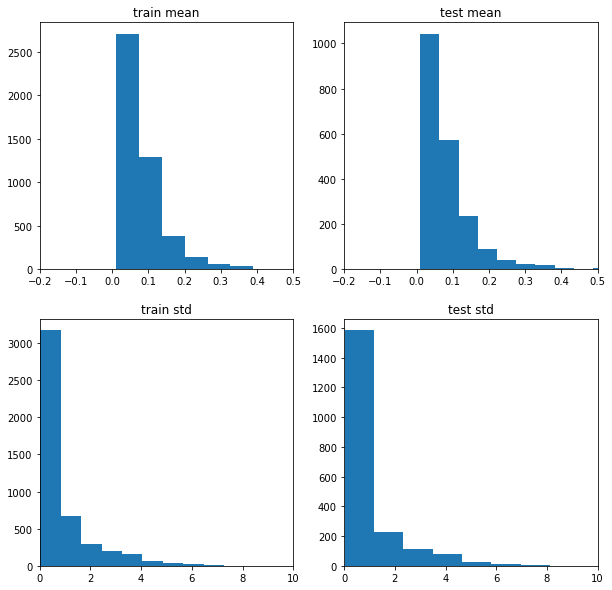

In [17]:
def plot_mean_std(ctx):
    plt.figure(figsize=(10, 10))
    plt.subplot(221)
    plt.hist(ctx.get_relevs("train").mean(axis=-1))
    plt.title("train mean")
    plt.xlim((-0.2, 0.5))
    plt.subplot(222)
    plt.hist(ctx.get_relevs("test").mean(axis=-1))
    plt.title("test mean")
    plt.xlim((-0.2, 0.5))
    plt.subplot(223)
    plt.hist(ctx.get_relevs("train").std(axis=-1))
    plt.title("train std")
    plt.xlim((0, 10))
    plt.subplot(224)
    plt.hist(ctx.get_relevs("test").std(axis=-1))
    plt.title("test std")
    plt.xlim((0, 10))
    plt.show()
    
plot_mean_std(ctx)

In [18]:
t = ctx.get_relevs("train")
key_games_before_norm = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

/var/tmp/ipykernel_278741/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

In [19]:
for sl in ctx.slices:
    ctx.get_relevs(sl)
    
    v = ctx.relevs[sl]
    
    ctx.relevs[sl] = (
        (v.T - v.mean(axis=-1))
        / v.std(axis=-1)
    ).T

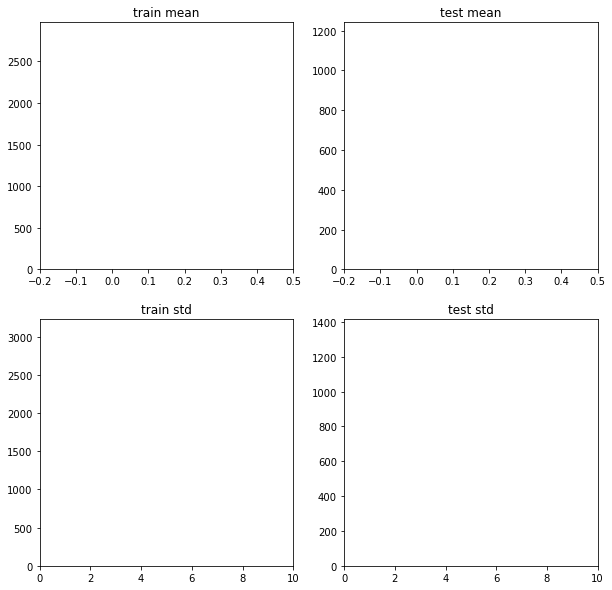

In [20]:
plot_mean_std(ctx)

In [21]:
t = ctx.get_relevs("train")
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")


ma = AnnCUR(ctx, key_games=key_games_before_norm)

ma.fit()
ma.get_score("train"), ma.get_score("test")

/var/tmp/ipykernel_278741/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.7104048234280792 0.40658572180578517 4644
np.mean(results), mse, len(results) =  0.7004424778761061 0.4559220913449976 2034
np.mean(results), mse, len(results) =  0.6913501291989664 0.4267612692250834 4644
np.mean(results), mse, len(results) =  0.6797345132743362 0.4692648601358897 2034


(0.6913501291989664, 0.6797345132743362)

In [66]:
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    # "Winit": "eye",
    # "Wfreeze": True,
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.2212871287128713 tf.Tensor(30.222328887377035, shape=(), dtype=float64) 101
slice = key, score = 0.2212871287128713
np.mean(results), mse, len(results) =  0.20805124892334195 tf.Tensor(30.311655932314295, shape=(), dtype=float64) 4644
slice = train, score = 0.20805124892334195
np.mean(results), mse, len(results) =  0.21015240904621438 tf.Tensor(28.31861013931341, shape=(), dtype=float64) 2034
slice = test, score = 0.21015240904621438

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5971287128712871 tf.Tensor(1885.5097119484565, shape=(), dtype=float64) 101
slice = key, score = 0.5971287128712871
np.mean(results), mse, len(results) =  0.6226851851851852 tf.Te


=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6767326732673266 tf.Tensor(12105.481979784588, shape=(), dtype=float64) 101
slice = key, score = 0.6767326732673266
np.mean(results), mse, len(results) =  0.699801894918174 tf.Tensor(10543.646434637787, shape=(), dtype=float64) 4644
slice = train, score = 0.699801894918174
np.mean(results), mse, len(results) =  0.6841347099311702 tf.Tensor(10804.426562659466, shape=(), dtype=float64) 2034
slice = test, score = 0.6841347099311702

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6833663366336632 tf.Tensor(12309.856636328805, shape=(), dtype=float64) 101
slice = key, score = 0.6833663366336632
np.mean(results), mse, len(results) =  0.7013975021533161 tf.Tensor(11935.273498541259, shape=(), dtype=float64) 4644
slice = train, score = 0.7013975021533161
np.mean(results), mse, len(results) =  0.6892477876106193 tf.Tensor(11897.62131538003, shape=(), dtype=float64) 2034
slice = test, score = 0.6892477876106193



np.mean(results), mse, len(results) =  0.6900442477876108 tf.Tensor(30251.816998950937, shape=(), dtype=float64) 2034
slice = test, score = 0.6900442477876108

=== Iteration 33000 ===
np.mean(results), mse, len(results) =  0.6913861386138616 tf.Tensor(31670.459826842518, shape=(), dtype=float64) 101
slice = key, score = 0.6913861386138616
np.mean(results), mse, len(results) =  0.7093927648578812 tf.Tensor(29179.943974029276, shape=(), dtype=float64) 4644
slice = train, score = 0.7093927648578812
np.mean(results), mse, len(results) =  0.6960963618485743 tf.Tensor(29358.53700872025, shape=(), dtype=float64) 2034
slice = test, score = 0.6960963618485743

=== Iteration 34000 ===
np.mean(results), mse, len(results) =  0.6902970297029702 tf.Tensor(32766.218702230002, shape=(), dtype=float64) 101
slice = key, score = 0.6902970297029702
np.mean(results), mse, len(results) =  0.7135357450473729 tf.Tensor(31527.327618121333, shape=(), dtype=float64) 4644
slice = train, score = 0.7135357450473729

np.mean(results), mse, len(results) =  0.7127820844099914 tf.Tensor(60307.06784482021, shape=(), dtype=float64) 4644
slice = train, score = 0.7127820844099914
np.mean(results), mse, len(results) =  0.7005998033431662 tf.Tensor(60622.94692483251, shape=(), dtype=float64) 2034
slice = test, score = 0.7005998033431662

=== Iteration 50000 ===
np.mean(results), mse, len(results) =  0.6828712871287126 tf.Tensor(68748.91534662386, shape=(), dtype=float64) 101
slice = key, score = 0.6828712871287126
np.mean(results), mse, len(results) =  0.7138953488372093 tf.Tensor(63573.74725539277, shape=(), dtype=float64) 4644
slice = train, score = 0.7138953488372093
np.mean(results), mse, len(results) =  0.7021583087512291 tf.Tensor(62781.95538456607, shape=(), dtype=float64) 2034
slice = test, score = 0.7021583087512291

=== Iteration 51000 ===
np.mean(results), mse, len(results) =  0.6951485148514851 tf.Tensor(80404.39515713218, shape=(), dtype=float64) 101
slice = key, score = 0.6951485148514851
np.m


=== Iteration 66000 ===
np.mean(results), mse, len(results) =  0.6956435643564356 tf.Tensor(119261.05503611929, shape=(), dtype=float64) 101
slice = key, score = 0.6956435643564356
np.mean(results), mse, len(results) =  0.7183182601205856 tf.Tensor(111273.40024264003, shape=(), dtype=float64) 4644
slice = train, score = 0.7183182601205856
np.mean(results), mse, len(results) =  0.7022763028515241 tf.Tensor(110979.30980093016, shape=(), dtype=float64) 2034
slice = test, score = 0.7022763028515241

=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.6986138613861385 tf.Tensor(140674.90839603115, shape=(), dtype=float64) 101
slice = key, score = 0.6986138613861385
np.mean(results), mse, len(results) =  0.7226378122308355 tf.Tensor(131819.6246389062, shape=(), dtype=float64) 4644
slice = train, score = 0.7226378122308355
np.mean(results), mse, len(results) =  0.7082890855457227 tf.Tensor(131839.05373204907, shape=(), dtype=float64) 2034
slice = test, score = 0.7082890855457227

...

np.mean(results), mse, len(results) =  0.697212389380531 tf.Tensor(57346894.593334295, shape=(), dtype=float64) 2034
slice = test, score = 0.697212389380531

=== Iteration 435000 ===
np.mean(results), mse, len(results) =  0.6835643564356436 tf.Tensor(72483053.67937003, shape=(), dtype=float64) 101
slice = key, score = 0.6835643564356436
np.mean(results), mse, len(results) =  0.7102282515073212 tf.Tensor(63394743.00040202, shape=(), dtype=float64) 4644
slice = train, score = 0.7102282515073212
np.mean(results), mse, len(results) =  0.696991150442478 tf.Tensor(64119325.04777981, shape=(), dtype=float64) 2034
slice = test, score = 0.696991150442478

=== Iteration 436000 ===
np.mean(results), mse, len(results) =  0.6852475247524753 tf.Tensor(81261788.56729777, shape=(), dtype=float64) 101
slice = key, score = 0.6852475247524753
np.mean(results), mse, len(results) =  0.7086541774332471 tf.Tensor(71553162.99616662, shape=(), dtype=float64) 4644
slice = train, score = 0.7086541774332471
np.me

np.mean(results), mse, len(results) =  0.7047286821705426 tf.Tensor(77928579.06653146, shape=(), dtype=float64) 4644
slice = train, score = 0.7047286821705426
np.mean(results), mse, len(results) =  0.6903195673549656 tf.Tensor(79388585.39342673, shape=(), dtype=float64) 2034
slice = test, score = 0.6903195673549656

=== Iteration 452000 ===
np.mean(results), mse, len(results) =  0.6872277227722772 tf.Tensor(92127864.79815431, shape=(), dtype=float64) 101
slice = key, score = 0.6872277227722772
np.mean(results), mse, len(results) =  0.7088135228251508 tf.Tensor(79262377.19445334, shape=(), dtype=float64) 4644
slice = train, score = 0.7088135228251508
np.mean(results), mse, len(results) =  0.69468534906588 tf.Tensor(79664527.12578402, shape=(), dtype=float64) 2034
slice = test, score = 0.69468534906588

=== Iteration 453000 ===
np.mean(results), mse, len(results) =  0.6805940594059405 tf.Tensor(95812808.36873041, shape=(), dtype=float64) 101
slice = key, score = 0.6805940594059405
np.mea


=== Iteration 468000 ===
np.mean(results), mse, len(results) =  0.694059405940594 tf.Tensor(91237063.68765712, shape=(), dtype=float64) 101
slice = key, score = 0.694059405940594
np.mean(results), mse, len(results) =  0.7116020671834626 tf.Tensor(78647745.40276864, shape=(), dtype=float64) 4644
slice = train, score = 0.7116020671834626
np.mean(results), mse, len(results) =  0.6976499508357915 tf.Tensor(81137946.35582022, shape=(), dtype=float64) 2034
slice = test, score = 0.6976499508357915

=== Iteration 469000 ===
np.mean(results), mse, len(results) =  0.6881188118811881 tf.Tensor(97608363.78954647, shape=(), dtype=float64) 101
slice = key, score = 0.6881188118811881
np.mean(results), mse, len(results) =  0.707543066322136 tf.Tensor(83061391.6255411, shape=(), dtype=float64) 4644
slice = train, score = 0.707543066322136
np.mean(results), mse, len(results) =  0.6921435594886923 tf.Tensor(85340808.90698917, shape=(), dtype=float64) 2034
slice = test, score = 0.6921435594886923

=== It

np.mean(results), mse, len(results) =  0.6982645034414946 tf.Tensor(97555783.50520886, shape=(), dtype=float64) 2034
slice = test, score = 0.6982645034414946

=== Iteration 485000 ===
np.mean(results), mse, len(results) =  0.687326732673267 tf.Tensor(114727082.677648, shape=(), dtype=float64) 101
slice = key, score = 0.687326732673267
np.mean(results), mse, len(results) =  0.7133570198105081 tf.Tensor(103949159.26252207, shape=(), dtype=float64) 4644
slice = train, score = 0.7133570198105081
np.mean(results), mse, len(results) =  0.7000491642084563 tf.Tensor(105267552.84684679, shape=(), dtype=float64) 2034
slice = test, score = 0.7000491642084563

=== Iteration 486000 ===
np.mean(results), mse, len(results) =  0.6795049504950494 tf.Tensor(127911680.92156881, shape=(), dtype=float64) 101
slice = key, score = 0.6795049504950494
np.mean(results), mse, len(results) =  0.7044939707149009 tf.Tensor(107716547.61640911, shape=(), dtype=float64) 4644
slice = train, score = 0.7044939707149009
n

412

In [22]:
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    "Winit": "eye",
    # "Wfreeze": True,
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.4063366336633663 tf.Tensor(126.8111925507462, shape=(), dtype=float64) 101
slice = key, score = 0.4063366336633663
np.mean(results), mse, len(results) =  0.4583548664944014 tf.Tensor(95.86369598572153, shape=(), dtype=float64) 4644
slice = train, score = 0.4583548664944014
np.mean(results), mse, len(results) =  0.44495575221238937 tf.Tensor(102.67904722060804, shape=(), dtype=float64) 2034
slice = test, score = 0.44495575221238937

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.6366336633663368 tf.Tensor(1109.0263859496931, shape=(), dtype=float64) 101
slice = key, score = 0.6366336633663368
np.mean(results), mse, len(results) =  0.6661649440137812 tf.Tenso


=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6759405940594058 tf.Tensor(3826.5877547241216, shape=(), dtype=float64) 101
slice = key, score = 0.6759405940594058
np.mean(results), mse, len(results) =  0.7009711455641688 tf.Tensor(3520.259904220298, shape=(), dtype=float64) 4644
slice = train, score = 0.7009711455641688
np.mean(results), mse, len(results) =  0.6884365781710914 tf.Tensor(3537.9348299294556, shape=(), dtype=float64) 2034
slice = test, score = 0.6884365781710914

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6835643564356435 tf.Tensor(4061.174189453358, shape=(), dtype=float64) 101
slice = key, score = 0.6835643564356435
np.mean(results), mse, len(results) =  0.7048062015503875 tf.Tensor(3712.1236110530303, shape=(), dtype=float64) 4644
slice = train, score = 0.7048062015503875
np.mean(results), mse, len(results) =  0.6916764995083579 tf.Tensor(3754.902063294571, shape=(), dtype=float64) 2034
slice = test, score = 0.6916764995083579



np.mean(results), mse, len(results) =  0.7013077679449361 tf.Tensor(7637.716981743294, shape=(), dtype=float64) 2034
slice = test, score = 0.7013077679449361

=== Iteration 33000 ===
np.mean(results), mse, len(results) =  0.7000000000000001 tf.Tensor(8563.244483451926, shape=(), dtype=float64) 101
slice = key, score = 0.7000000000000001
np.mean(results), mse, len(results) =  0.7225172265288544 tf.Tensor(7684.114351694719, shape=(), dtype=float64) 4644
slice = train, score = 0.7225172265288544
np.mean(results), mse, len(results) =  0.7063470993117011 tf.Tensor(7778.683181309937, shape=(), dtype=float64) 2034
slice = test, score = 0.7063470993117011

=== Iteration 34000 ===
np.mean(results), mse, len(results) =  0.6895049504950496 tf.Tensor(9437.201735921297, shape=(), dtype=float64) 101
slice = key, score = 0.6895049504950496
np.mean(results), mse, len(results) =  0.719052540913006 tf.Tensor(8768.016424089412, shape=(), dtype=float64) 4644
slice = train, score = 0.719052540913006
np.mea

np.mean(results), mse, len(results) =  0.7255103359173126 tf.Tensor(15205.727845205249, shape=(), dtype=float64) 4644
slice = train, score = 0.7255103359173126
np.mean(results), mse, len(results) =  0.7101769911504425 tf.Tensor(15479.929591859787, shape=(), dtype=float64) 2034
slice = test, score = 0.7101769911504425

=== Iteration 50000 ===
np.mean(results), mse, len(results) =  0.6993069306930693 tf.Tensor(16725.770263603117, shape=(), dtype=float64) 101
slice = key, score = 0.6993069306930693
np.mean(results), mse, len(results) =  0.7285422049956933 tf.Tensor(14958.390891358114, shape=(), dtype=float64) 4644
slice = train, score = 0.7285422049956933
np.mean(results), mse, len(results) =  0.7116519174041298 tf.Tensor(15133.762565756504, shape=(), dtype=float64) 2034
slice = test, score = 0.7116519174041298

=== Iteration 51000 ===
np.mean(results), mse, len(results) =  0.7009900990099008 tf.Tensor(16528.112097259473, shape=(), dtype=float64) 101
slice = key, score = 0.700990099009900


=== Iteration 66000 ===
np.mean(results), mse, len(results) =  0.7062376237623762 tf.Tensor(27803.33412208276, shape=(), dtype=float64) 101
slice = key, score = 0.7062376237623762
np.mean(results), mse, len(results) =  0.7312510766580533 tf.Tensor(25948.502009021708, shape=(), dtype=float64) 4644
slice = train, score = 0.7312510766580533
np.mean(results), mse, len(results) =  0.7148131760078663 tf.Tensor(26008.75714842186, shape=(), dtype=float64) 2034
slice = test, score = 0.7148131760078663

=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.7049504950495051 tf.Tensor(27297.190092846904, shape=(), dtype=float64) 101
slice = key, score = 0.7049504950495051
np.mean(results), mse, len(results) =  0.7329995693367787 tf.Tensor(24797.9493938068, shape=(), dtype=float64) 4644
slice = train, score = 0.7329995693367787
np.mean(results), mse, len(results) =  0.7182300884955752 tf.Tensor(24841.47789469331, shape=(), dtype=float64) 2034
slice = test, score = 0.7182300884955752

==

...

np.mean(results), mse, len(results) =  0.7280404823428078 tf.Tensor(12177090.93907194, shape=(), dtype=float64) 4644
slice = train, score = 0.7280404823428078
np.mean(results), mse, len(results) =  0.7112831858407079 tf.Tensor(12809746.305945039, shape=(), dtype=float64) 2034
slice = test, score = 0.7112831858407079

=== Iteration 437000 ===
np.mean(results), mse, len(results) =  0.6977227722772276 tf.Tensor(13911893.670742018, shape=(), dtype=float64) 101
slice = key, score = 0.6977227722772276
np.mean(results), mse, len(results) =  0.7243540051679586 tf.Tensor(11375751.630075162, shape=(), dtype=float64) 4644
slice = train, score = 0.7243540051679586
np.mean(results), mse, len(results) =  0.7077433628318583 tf.Tensor(11899531.87922877, shape=(), dtype=float64) 2034
slice = test, score = 0.7077433628318583

=== Iteration 438000 ===
np.mean(results), mse, len(results) =  0.7032673267326732 tf.Tensor(15463762.904182566, shape=(), dtype=float64) 101
slice = key, score = 0.703267326732673


=== Iteration 453000 ===
np.mean(results), mse, len(results) =  0.678910891089109 tf.Tensor(15065202.67151518, shape=(), dtype=float64) 101
slice = key, score = 0.678910891089109
np.mean(results), mse, len(results) =  0.7032644272179156 tf.Tensor(11658890.527005637, shape=(), dtype=float64) 4644
slice = train, score = 0.7032644272179156
np.mean(results), mse, len(results) =  0.69062930186824 tf.Tensor(12131222.361696897, shape=(), dtype=float64) 2034
slice = test, score = 0.69062930186824

=== Iteration 454000 ===
np.mean(results), mse, len(results) =  0.6959405940594059 tf.Tensor(16512108.542450033, shape=(), dtype=float64) 101
slice = key, score = 0.6959405940594059
np.mean(results), mse, len(results) =  0.7216537467700259 tf.Tensor(12779332.374339502, shape=(), dtype=float64) 4644
slice = train, score = 0.7216537467700259
np.mean(results), mse, len(results) =  0.7068387413962636 tf.Tensor(13225210.967458714, shape=(), dtype=float64) 2034
slice = test, score = 0.7068387413962636

==

np.mean(results), mse, len(results) =  0.7283010335917313 tf.Tensor(15473599.590540903, shape=(), dtype=float64) 4644
slice = train, score = 0.7283010335917313
np.mean(results), mse, len(results) =  0.715142576204523 tf.Tensor(16167109.902518451, shape=(), dtype=float64) 2034
slice = test, score = 0.715142576204523

=== Iteration 470000 ===
np.mean(results), mse, len(results) =  0.7068316831683168 tf.Tensor(17151705.86293418, shape=(), dtype=float64) 101
slice = key, score = 0.7068316831683168
np.mean(results), mse, len(results) =  0.7308484065460809 tf.Tensor(15192454.68474142, shape=(), dtype=float64) 4644
slice = train, score = 0.7308484065460809
np.mean(results), mse, len(results) =  0.7164552605703047 tf.Tensor(15520710.76593741, shape=(), dtype=float64) 2034
slice = test, score = 0.7164552605703047

=== Iteration 471000 ===
np.mean(results), mse, len(results) =  0.7030693069306931 tf.Tensor(20310199.147325084, shape=(), dtype=float64) 101
slice = key, score = 0.7030693069306931
n


=== Iteration 486000 ===
np.mean(results), mse, len(results) =  0.695841584158416 tf.Tensor(25181686.416714113, shape=(), dtype=float64) 101
slice = key, score = 0.695841584158416
np.mean(results), mse, len(results) =  0.7237984496124031 tf.Tensor(21420139.211088542, shape=(), dtype=float64) 4644
slice = train, score = 0.7237984496124031
np.mean(results), mse, len(results) =  0.7087463126843658 tf.Tensor(21973874.365625147, shape=(), dtype=float64) 2034
slice = test, score = 0.7087463126843658

=== Iteration 487000 ===
np.mean(results), mse, len(results) =  0.7010891089108913 tf.Tensor(26309119.695548642, shape=(), dtype=float64) 101
slice = key, score = 0.7010891089108913
np.mean(results), mse, len(results) =  0.7233505598621878 tf.Tensor(22761449.87940438, shape=(), dtype=float64) 4644
slice = train, score = 0.7233505598621878
np.mean(results), mse, len(results) =  0.7082546705998034 tf.Tensor(23502476.796328146, shape=(), dtype=float64) 2034
slice = test, score = 0.7082546705998034

412

In [26]:
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    "Winit": "eye",
    # "Wfreeze": True,
})

m.fit()
m.get_score("train"), m.get_score("test")

del m
gc.collect()

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.41564356435643557 tf.Tensor(117.43170274185194, shape=(), dtype=float64) 101
slice = key, score = 0.41564356435643557
np.mean(results), mse, len(results) =  0.4718195521102498 tf.Tensor(98.45765277541201, shape=(), dtype=float64) 4644
slice = train, score = 0.4718195521102498
np.mean(results), mse, len(results) =  0.46283185840707963 tf.Tensor(102.73288183297896, shape=(), dtype=float64) 2034
slice = test, score = 0.46283185840707963

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.6330693069306931 tf.Tensor(1210.5769694876876, shape=(), dtype=float64) 101
slice = key, score = 0.6330693069306931
np.mean(results), mse, len(results) =  0.6587403100775195 tf.Te


=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6695049504950494 tf.Tensor(4107.422482327045, shape=(), dtype=float64) 101
slice = key, score = 0.6695049504950494
np.mean(results), mse, len(results) =  0.6968044788975022 tf.Tensor(3417.490867448134, shape=(), dtype=float64) 4644
slice = train, score = 0.6968044788975022
np.mean(results), mse, len(results) =  0.6830285152409046 tf.Tensor(3466.6390614899124, shape=(), dtype=float64) 2034
slice = test, score = 0.6830285152409046

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.68980198019802 tf.Tensor(3243.0138732199684, shape=(), dtype=float64) 101
slice = key, score = 0.68980198019802
np.mean(results), mse, len(results) =  0.7096834625322997 tf.Tensor(3030.4404891614195, shape=(), dtype=float64) 4644
slice = train, score = 0.7096834625322997
np.mean(results), mse, len(results) =  0.6958947885939036 tf.Tensor(3004.4537560416384, shape=(), dtype=float64) 2034
slice = test, score = 0.6958947885939036

===

np.mean(results), mse, len(results) =  0.6916470009832842 tf.Tensor(7238.73479478221, shape=(), dtype=float64) 2034
slice = test, score = 0.6916470009832842

=== Iteration 33000 ===
np.mean(results), mse, len(results) =  0.693069306930693 tf.Tensor(8274.543497704923, shape=(), dtype=float64) 101
slice = key, score = 0.693069306930693
np.mean(results), mse, len(results) =  0.7198234280792419 tf.Tensor(7662.33691886923, shape=(), dtype=float64) 4644
slice = train, score = 0.7198234280792419
np.mean(results), mse, len(results) =  0.703431661750246 tf.Tensor(7688.2228006345995, shape=(), dtype=float64) 2034
slice = test, score = 0.703431661750246

=== Iteration 34000 ===
np.mean(results), mse, len(results) =  0.682970297029703 tf.Tensor(8830.066010111655, shape=(), dtype=float64) 101
slice = key, score = 0.682970297029703
np.mean(results), mse, len(results) =  0.710725667527993 tf.Tensor(7820.103287310057, shape=(), dtype=float64) 4644
slice = train, score = 0.710725667527993
np.mean(resul

np.mean(results), mse, len(results) =  0.7140439276485788 tf.Tensor(12150.36043848302, shape=(), dtype=float64) 4644
slice = train, score = 0.7140439276485788
np.mean(results), mse, len(results) =  0.7009931170108162 tf.Tensor(12211.503612369484, shape=(), dtype=float64) 2034
slice = test, score = 0.7009931170108162

=== Iteration 50000 ===
np.mean(results), mse, len(results) =  0.6975247524752474 tf.Tensor(14521.07061193439, shape=(), dtype=float64) 101
slice = key, score = 0.6975247524752474
np.mean(results), mse, len(results) =  0.7273858742463394 tf.Tensor(13567.30685334361, shape=(), dtype=float64) 4644
slice = train, score = 0.7273858742463394
np.mean(results), mse, len(results) =  0.712841691248771 tf.Tensor(13483.144265741455, shape=(), dtype=float64) 2034
slice = test, score = 0.712841691248771

=== Iteration 51000 ===
np.mean(results), mse, len(results) =  0.7052475247524751 tf.Tensor(14760.835223561504, shape=(), dtype=float64) 101
slice = key, score = 0.7052475247524751
np.


=== Iteration 66000 ===
np.mean(results), mse, len(results) =  0.6952475247524754 tf.Tensor(23521.010541590527, shape=(), dtype=float64) 101
slice = key, score = 0.6952475247524754
np.mean(results), mse, len(results) =  0.7255835486649439 tf.Tensor(21381.279121162548, shape=(), dtype=float64) 4644
slice = train, score = 0.7255835486649439
np.mean(results), mse, len(results) =  0.7095919370698132 tf.Tensor(21609.35739345978, shape=(), dtype=float64) 2034
slice = test, score = 0.7095919370698132

=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.70009900990099 tf.Tensor(27731.890481555998, shape=(), dtype=float64) 101
slice = key, score = 0.70009900990099
np.mean(results), mse, len(results) =  0.7248385012919897 tf.Tensor(25791.49831274919, shape=(), dtype=float64) 4644
slice = train, score = 0.7248385012919897
np.mean(results), mse, len(results) =  0.709267453294002 tf.Tensor(25822.361668015263, shape=(), dtype=float64) 2034
slice = test, score = 0.709267453294002

=== I

...

np.mean(results), mse, len(results) =  0.7264448751076658 tf.Tensor(12809757.012318537, shape=(), dtype=float64) 4644
slice = train, score = 0.7264448751076658
np.mean(results), mse, len(results) =  0.7108456243854474 tf.Tensor(13513336.50884273, shape=(), dtype=float64) 2034
slice = test, score = 0.7108456243854474

=== Iteration 451000 ===
np.mean(results), mse, len(results) =  0.7024752475247528 tf.Tensor(14804759.234993622, shape=(), dtype=float64) 101
slice = key, score = 0.7024752475247528
np.mean(results), mse, len(results) =  0.7269099913867356 tf.Tensor(12539629.300531423, shape=(), dtype=float64) 4644
slice = train, score = 0.7269099913867356
np.mean(results), mse, len(results) =  0.7096656833824976 tf.Tensor(13249520.57185778, shape=(), dtype=float64) 2034
slice = test, score = 0.7096656833824976

=== Iteration 452000 ===
np.mean(results), mse, len(results) =  0.6996039603960397 tf.Tensor(17368104.495902006, shape=(), dtype=float64) 101
slice = key, score = 0.699603960396039


=== Iteration 467000 ===
np.mean(results), mse, len(results) =  0.7047524752475248 tf.Tensor(18336000.419491, shape=(), dtype=float64) 101
slice = key, score = 0.7047524752475248
np.mean(results), mse, len(results) =  0.7279112833763997 tf.Tensor(14326701.523476075, shape=(), dtype=float64) 4644
slice = train, score = 0.7279112833763997
np.mean(results), mse, len(results) =  0.7121878072763028 tf.Tensor(15189468.14999849, shape=(), dtype=float64) 2034
slice = test, score = 0.7121878072763028

=== Iteration 468000 ===
np.mean(results), mse, len(results) =  0.7032673267326732 tf.Tensor(19062530.704511337, shape=(), dtype=float64) 101
slice = key, score = 0.7032673267326732
np.mean(results), mse, len(results) =  0.7292204995693368 tf.Tensor(14898893.957930643, shape=(), dtype=float64) 4644
slice = train, score = 0.7292204995693368
np.mean(results), mse, len(results) =  0.7127728613569322 tf.Tensor(15728888.155643929, shape=(), dtype=float64) 2034
slice = test, score = 0.7127728613569322


np.mean(results), mse, len(results) =  0.703992133726647 tf.Tensor(18423188.54021264, shape=(), dtype=float64) 2034
slice = test, score = 0.703992133726647

=== Iteration 484000 ===
np.mean(results), mse, len(results) =  0.7070297029702971 tf.Tensor(23090612.622605555, shape=(), dtype=float64) 101
slice = key, score = 0.7070297029702971
np.mean(results), mse, len(results) =  0.7310745047372954 tf.Tensor(18866360.05075114, shape=(), dtype=float64) 4644
slice = train, score = 0.7310745047372954
np.mean(results), mse, len(results) =  0.711637168141593 tf.Tensor(20002901.844821118, shape=(), dtype=float64) 2034
slice = test, score = 0.711637168141593

=== Iteration 485000 ===
np.mean(results), mse, len(results) =  0.6998019801980198 tf.Tensor(19893073.984999344, shape=(), dtype=float64) 101
slice = key, score = 0.6998019801980198
np.mean(results), mse, len(results) =  0.7217721791559001 tf.Tensor(16478153.949767984, shape=(), dtype=float64) 4644
slice = train, score = 0.7217721791559001
np

np.mean(results), mse, len(results) =  0.7251894918173988 tf.Tensor(19131174.07310584, shape=(), dtype=float64) 4644
np.mean(results), mse, len(results) =  0.7105801376597838 tf.Tensor(20013147.177103046, shape=(), dtype=float64) 2034


412

In [ ]:
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    "Winit": "eye",
    # "Wfreeze": True,
    "normalize_embs": False
})

m.fit()
m.get_score("train"), m.get_score("test")

del m
gc.collect()

In [22]:
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005,
    "Winit": "eye",
    "Wfreeze": True,
    "normalize_embs": False
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.1371287128712871 tf.Tensor(1195.9490628687315, shape=(), dtype=float64) 101
slice = key, score = 0.1371287128712871
np.mean(results), mse, len(results) =  0.14525193798449615 tf.Tensor(1542.733581406019, shape=(), dtype=float64) 4644
slice = train, score = 0.14525193798449615
np.mean(results), mse, len(results) =  0.146125860373648 tf.Tensor(1545.6095710002003, shape=(), dtype=float64) 2034
slice = test, score = 0.146125860373648

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5744554455445545 tf.Tensor(10955.860041139194, shape=(), dtype=float64) 101
slice = key, score = 0.5744554455445545
np.mean(results), mse, len(results) =  0.5930943152454781 tf.Tensor


=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6394059405940594 tf.Tensor(44592.08178783292, shape=(), dtype=float64) 101
slice = key, score = 0.6394059405940594
np.mean(results), mse, len(results) =  0.6596447028423773 tf.Tensor(43372.9315215264, shape=(), dtype=float64) 4644
slice = train, score = 0.6596447028423773
np.mean(results), mse, len(results) =  0.6548279252704032 tf.Tensor(44894.32649933337, shape=(), dtype=float64) 2034
slice = test, score = 0.6548279252704032

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6435643564356436 tf.Tensor(37797.790366962094, shape=(), dtype=float64) 101
slice = key, score = 0.6435643564356436
np.mean(results), mse, len(results) =  0.6660335917312662 tf.Tensor(37330.47028238801, shape=(), dtype=float64) 4644
slice = train, score = 0.6660335917312662
np.mean(results), mse, len(results) =  0.6614110127826942 tf.Tensor(38693.01481261009, shape=(), dtype=float64) 2034
slice = test, score = 0.6614110127826942

===

np.mean(results), mse, len(results) =  0.6758554572271387 tf.Tensor(76922.63612680175, shape=(), dtype=float64) 2034
slice = test, score = 0.6758554572271387

=== Iteration 33000 ===
np.mean(results), mse, len(results) =  0.6635643564356435 tf.Tensor(72191.44691531143, shape=(), dtype=float64) 101
slice = key, score = 0.6635643564356435
np.mean(results), mse, len(results) =  0.6872071490094745 tf.Tensor(60285.137857272384, shape=(), dtype=float64) 4644
slice = train, score = 0.6872071490094745
np.mean(results), mse, len(results) =  0.6814454277286135 tf.Tensor(63983.27496369168, shape=(), dtype=float64) 2034
slice = test, score = 0.6814454277286135

=== Iteration 34000 ===
np.mean(results), mse, len(results) =  0.6636633663366337 tf.Tensor(86312.88847940159, shape=(), dtype=float64) 101
slice = key, score = 0.6636633663366337
np.mean(results), mse, len(results) =  0.6853940568475452 tf.Tensor(75232.17552381684, shape=(), dtype=float64) 4644
slice = train, score = 0.6853940568475452
np.

np.mean(results), mse, len(results) =  0.6938802756244616 tf.Tensor(142738.88738305328, shape=(), dtype=float64) 4644
slice = train, score = 0.6938802756244616
np.mean(results), mse, len(results) =  0.6875762045231072 tf.Tensor(155846.09203043475, shape=(), dtype=float64) 2034
slice = test, score = 0.6875762045231072

=== Iteration 50000 ===
np.mean(results), mse, len(results) =  0.6753465346534653 tf.Tensor(169013.82829464195, shape=(), dtype=float64) 101
slice = key, score = 0.6753465346534653
np.mean(results), mse, len(results) =  0.6908570198105082 tf.Tensor(124376.11052102936, shape=(), dtype=float64) 4644
slice = train, score = 0.6908570198105082
np.mean(results), mse, len(results) =  0.6849016715830875 tf.Tensor(135718.29218492107, shape=(), dtype=float64) 2034
slice = test, score = 0.6849016715830875

=== Iteration 51000 ===
np.mean(results), mse, len(results) =  0.666930693069307 tf.Tensor(211976.61401810823, shape=(), dtype=float64) 101
slice = key, score = 0.666930693069307



=== Iteration 66000 ===
np.mean(results), mse, len(results) =  0.6715841584158415 tf.Tensor(338550.15682357864, shape=(), dtype=float64) 101
slice = key, score = 0.6715841584158415
np.mean(results), mse, len(results) =  0.6947782084409991 tf.Tensor(267685.27688861295, shape=(), dtype=float64) 4644
slice = train, score = 0.6947782084409991
np.mean(results), mse, len(results) =  0.6892527040314651 tf.Tensor(285353.1881585651, shape=(), dtype=float64) 2034
slice = test, score = 0.6892527040314651

=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.6752475247524753 tf.Tensor(331793.51274951134, shape=(), dtype=float64) 101
slice = key, score = 0.6752475247524753
np.mean(results), mse, len(results) =  0.6976894918173987 tf.Tensor(246717.8329279947, shape=(), dtype=float64) 4644
slice = train, score = 0.6976894918173987
np.mean(results), mse, len(results) =  0.6932055063913471 tf.Tensor(265689.1404604729, shape=(), dtype=float64) 2034
slice = test, score = 0.6932055063913471



...

np.mean(results), mse, len(results) =  0.6816175024582104 tf.Tensor(17409207.377937973, shape=(), dtype=float64) 2034
slice = test, score = 0.6816175024582104

=== Iteration 234000 ===
np.mean(results), mse, len(results) =  0.6738613861386139 tf.Tensor(20659964.312226284, shape=(), dtype=float64) 101
slice = key, score = 0.6738613861386139
np.mean(results), mse, len(results) =  0.6939039621016365 tf.Tensor(14401664.440499052, shape=(), dtype=float64) 4644
slice = train, score = 0.6939039621016365
np.mean(results), mse, len(results) =  0.6882645034414946 tf.Tensor(15916115.133825785, shape=(), dtype=float64) 2034
slice = test, score = 0.6882645034414946

=== Iteration 235000 ===
np.mean(results), mse, len(results) =  0.6673267326732673 tf.Tensor(21099335.018247087, shape=(), dtype=float64) 101
slice = key, score = 0.6673267326732673
np.mean(results), mse, len(results) =  0.6943260120585701 tf.Tensor(15834295.32778565, shape=(), dtype=float64) 4644
slice = train, score = 0.69432601205857

np.mean(results), mse, len(results) =  0.6741881998277348 tf.Tensor(30214741.144212577, shape=(), dtype=float64) 4644
slice = train, score = 0.6741881998277348
np.mean(results), mse, len(results) =  0.6688987217305801 tf.Tensor(32367437.94440818, shape=(), dtype=float64) 2034
slice = test, score = 0.6688987217305801

=== Iteration 251000 ===
np.mean(results), mse, len(results) =  0.661980198019802 tf.Tensor(37923223.98833027, shape=(), dtype=float64) 101
slice = key, score = 0.661980198019802
np.mean(results), mse, len(results) =  0.684306632213609 tf.Tensor(31331331.580121867, shape=(), dtype=float64) 4644
slice = train, score = 0.684306632213609
np.mean(results), mse, len(results) =  0.6798475909537857 tf.Tensor(33354861.016724553, shape=(), dtype=float64) 2034
slice = test, score = 0.6798475909537857

=== Iteration 252000 ===
np.mean(results), mse, len(results) =  0.6717821782178217 tf.Tensor(31378897.376639754, shape=(), dtype=float64) 101
slice = key, score = 0.6717821782178217
np


=== Iteration 267000 ===
np.mean(results), mse, len(results) =  0.6585148514851484 tf.Tensor(52208085.12182911, shape=(), dtype=float64) 101
slice = key, score = 0.6585148514851484
np.mean(results), mse, len(results) =  0.6830124892334195 tf.Tensor(41657674.20753832, shape=(), dtype=float64) 4644
slice = train, score = 0.6830124892334195
np.mean(results), mse, len(results) =  0.6773451327433628 tf.Tensor(45425158.334890954, shape=(), dtype=float64) 2034
slice = test, score = 0.6773451327433628

=== Iteration 268000 ===
np.mean(results), mse, len(results) =  0.6695049504950495 tf.Tensor(44174261.693641834, shape=(), dtype=float64) 101
slice = key, score = 0.6695049504950495
np.mean(results), mse, len(results) =  0.694371231696813 tf.Tensor(34031791.24145456, shape=(), dtype=float64) 4644
slice = train, score = 0.694371231696813
np.mean(results), mse, len(results) =  0.6883235004916421 tf.Tensor(37033697.00933196, shape=(), dtype=float64) 2034
slice = test, score = 0.6883235004916421

=

np.mean(results), mse, len(results) =  0.6781907571288103 tf.Tensor(49455452.642888695, shape=(), dtype=float64) 2034
slice = test, score = 0.6781907571288103

=== Iteration 284000 ===
np.mean(results), mse, len(results) =  0.678118811881188 tf.Tensor(46494461.54171851, shape=(), dtype=float64) 101
slice = key, score = 0.678118811881188
np.mean(results), mse, len(results) =  0.6972502153316107 tf.Tensor(34299409.45572098, shape=(), dtype=float64) 4644
slice = train, score = 0.6972502153316107
np.mean(results), mse, len(results) =  0.6910521140609636 tf.Tensor(37279048.682829715, shape=(), dtype=float64) 2034
slice = test, score = 0.6910521140609636

=== Iteration 285000 ===
np.mean(results), mse, len(results) =  0.6693069306930692 tf.Tensor(63339893.87477086, shape=(), dtype=float64) 101
slice = key, score = 0.6693069306930692
np.mean(results), mse, len(results) =  0.6854866494401378 tf.Tensor(50297727.11101251, shape=(), dtype=float64) 4644
slice = train, score = 0.6854866494401378
np


KeyboardInterrupt



In [ ]:
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0001,
    "Winit": "eye",
    "Wfreeze": True,
    "normalize_embs": False
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.26435643564356437 tf.Tensor(583.4775677352304, shape=(), dtype=float64) 101
slice = key, score = 0.26435643564356437
np.mean(results), mse, len(results) =  0.281057278208441 tf.Tensor(934.1924879039063, shape=(), dtype=float64) 4644
slice = train, score = 0.281057278208441
np.mean(results), mse, len(results) =  0.27861356932153397 tf.Tensor(946.8229888643489, shape=(), dtype=float64) 2034
slice = test, score = 0.27861356932153397

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5258415841584159 tf.Tensor(3900.5989161926705, shape=(), dtype=float64) 101
slice = key, score = 0.5258415841584159
np.mean(results), mse, len(results) =  0.5526614987080104 tf.Tensor


=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6265346534653465 tf.Tensor(2861.590789466376, shape=(), dtype=float64) 101
slice = key, score = 0.6265346534653465
np.mean(results), mse, len(results) =  0.6509862187769165 tf.Tensor(3638.5719692664466, shape=(), dtype=float64) 4644
slice = train, score = 0.6509862187769165
np.mean(results), mse, len(results) =  0.6455998033431662 tf.Tensor(3765.2612766839084, shape=(), dtype=float64) 2034
slice = test, score = 0.6455998033431662

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.6288118811881189 tf.Tensor(2532.118594030141, shape=(), dtype=float64) 101
slice = key, score = 0.6288118811881189
np.mean(results), mse, len(results) =  0.6502627045650302 tf.Tensor(3186.198905614829, shape=(), dtype=float64) 4644
slice = train, score = 0.6502627045650302
np.mean(results), mse, len(results) =  0.6450540806293018 tf.Tensor(3295.347361783589, shape=(), dtype=float64) 2034
slice = test, score = 0.6450540806293018

=

np.mean(results), mse, len(results) =  0.6598082595870206 tf.Tensor(1911.8449901103024, shape=(), dtype=float64) 2034
slice = test, score = 0.6598082595870206

=== Iteration 34000 ===
np.mean(results), mse, len(results) =  0.6532673267326733 tf.Tensor(1836.43306710399, shape=(), dtype=float64) 101
slice = key, score = 0.6532673267326733
np.mean(results), mse, len(results) =  0.6732428940568476 tf.Tensor(1934.6844169746855, shape=(), dtype=float64) 4644
slice = train, score = 0.6732428940568476
np.mean(results), mse, len(results) =  0.6671878072763028 tf.Tensor(2010.9103364298212, shape=(), dtype=float64) 2034
slice = test, score = 0.6671878072763028

=== Iteration 35000 ===
np.mean(results), mse, len(results) =  0.6470297029702972 tf.Tensor(2036.977309620108, shape=(), dtype=float64) 101
slice = key, score = 0.6470297029702972
np.mean(results), mse, len(results) =  0.672941429801895 tf.Tensor(2165.356349157213, shape=(), dtype=float64) 4644
slice = train, score = 0.672941429801895
np.m

np.mean(results), mse, len(results) =  0.6847394487510766 tf.Tensor(1648.5799615475137, shape=(), dtype=float64) 4644
slice = train, score = 0.6847394487510766
np.mean(results), mse, len(results) =  0.6784906588003933 tf.Tensor(1721.5480298915309, shape=(), dtype=float64) 2034
slice = test, score = 0.6784906588003933

=== Iteration 51000 ===
np.mean(results), mse, len(results) =  0.6631683168316831 tf.Tensor(1553.147452222416, shape=(), dtype=float64) 101
slice = key, score = 0.6631683168316831
np.mean(results), mse, len(results) =  0.6886089577950043 tf.Tensor(1451.5371493442185, shape=(), dtype=float64) 4644
slice = train, score = 0.6886089577950043
np.mean(results), mse, len(results) =  0.6824090462143559 tf.Tensor(1524.145993804381, shape=(), dtype=float64) 2034
slice = test, score = 0.6824090462143559

=== Iteration 52000 ===
np.mean(results), mse, len(results) =  0.665940594059406 tf.Tensor(1574.3761231475796, shape=(), dtype=float64) 101
slice = key, score = 0.665940594059406
np


=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.6793069306930694 tf.Tensor(1352.1360343923518, shape=(), dtype=float64) 101
slice = key, score = 0.6793069306930694
np.mean(results), mse, len(results) =  0.7021167097329888 tf.Tensor(1175.2950083247276, shape=(), dtype=float64) 4644
slice = train, score = 0.7021167097329888
np.mean(results), mse, len(results) =  0.6953392330383482 tf.Tensor(1244.406884145719, shape=(), dtype=float64) 2034
slice = test, score = 0.6953392330383482

=== Iteration 68000 ===
np.mean(results), mse, len(results) =  0.675049504950495 tf.Tensor(1494.231808466533, shape=(), dtype=float64) 101
slice = key, score = 0.675049504950495
np.mean(results), mse, len(results) =  0.696520241171404 tf.Tensor(1335.6289760090826, shape=(), dtype=float64) 4644
slice = train, score = 0.696520241171404
np.mean(results), mse, len(results) =  0.6902409046214356 tf.Tensor(1406.8850852953544, shape=(), dtype=float64) 2034
slice = test, score = 0.6902409046214356

===

...

np.mean(results), mse, len(results) =  0.7336218776916451 tf.Tensor(866.8390017681179, shape=(), dtype=float64) 4644
slice = train, score = 0.7336218776916451
np.mean(results), mse, len(results) =  0.7253588987217306 tf.Tensor(904.957602222629, shape=(), dtype=float64) 2034
slice = test, score = 0.7253588987217306

=== Iteration 253000 ===
np.mean(results), mse, len(results) =  0.7118811881188121 tf.Tensor(1010.8636138885054, shape=(), dtype=float64) 101
slice = key, score = 0.7118811881188121
np.mean(results), mse, len(results) =  0.7347329888027562 tf.Tensor(834.1616105997592, shape=(), dtype=float64) 4644
slice = train, score = 0.7347329888027562
np.mean(results), mse, len(results) =  0.7265830875122911 tf.Tensor(874.2040934628794, shape=(), dtype=float64) 2034
slice = test, score = 0.7265830875122911

=== Iteration 254000 ===
np.mean(results), mse, len(results) =  0.7183168316831683 tf.Tensor(1056.6713052719656, shape=(), dtype=float64) 101
slice = key, score = 0.7183168316831683
n


=== Iteration 269000 ===
np.mean(results), mse, len(results) =  0.7155445544554456 tf.Tensor(1134.9283657971666, shape=(), dtype=float64) 101
slice = key, score = 0.7155445544554456
np.mean(results), mse, len(results) =  0.7337812230835488 tf.Tensor(946.1578881714604, shape=(), dtype=float64) 4644
slice = train, score = 0.7337812230835488
np.mean(results), mse, len(results) =  0.7253097345132743 tf.Tensor(988.3429520187731, shape=(), dtype=float64) 2034
slice = test, score = 0.7253097345132743

=== Iteration 270000 ===
np.mean(results), mse, len(results) =  0.7136633663366336 tf.Tensor(1140.3543649302637, shape=(), dtype=float64) 101
slice = key, score = 0.7136633663366336
np.mean(results), mse, len(results) =  0.7309969853574505 tf.Tensor(930.7168368769891, shape=(), dtype=float64) 4644
slice = train, score = 0.7309969853574505
np.mean(results), mse, len(results) =  0.7229891838741396 tf.Tensor(978.2590444639246, shape=(), dtype=float64) 2034
slice = test, score = 0.7229891838741396


np.mean(results), mse, len(results) =  0.7281219272369714 tf.Tensor(940.3785353680347, shape=(), dtype=float64) 2034
slice = test, score = 0.7281219272369714

=== Iteration 286000 ===
np.mean(results), mse, len(results) =  0.7155445544554454 tf.Tensor(1119.2580647540217, shape=(), dtype=float64) 101
slice = key, score = 0.7155445544554454
np.mean(results), mse, len(results) =  0.7365482342807924 tf.Tensor(903.9682575997948, shape=(), dtype=float64) 4644
slice = train, score = 0.7365482342807924
np.mean(results), mse, len(results) =  0.7285889872173058 tf.Tensor(946.9763631983219, shape=(), dtype=float64) 2034
slice = test, score = 0.7285889872173058

=== Iteration 287000 ===
np.mean(results), mse, len(results) =  0.7211881188118813 tf.Tensor(1091.0564895387213, shape=(), dtype=float64) 101
slice = key, score = 0.7211881188118813
np.mean(results), mse, len(results) =  0.7404608096468561 tf.Tensor(885.517626739497, shape=(), dtype=float64) 4644
slice = train, score = 0.7404608096468561
n

np.mean(results), mse, len(results) =  0.7362424633936262 tf.Tensor(947.4645008043783, shape=(), dtype=float64) 4644
slice = train, score = 0.7362424633936262
np.mean(results), mse, len(results) =  0.7281907571288103 tf.Tensor(986.1249691662647, shape=(), dtype=float64) 2034
slice = test, score = 0.7281907571288103

=== Iteration 303000 ===
np.mean(results), mse, len(results) =  0.7154455445544553 tf.Tensor(1100.1963071801501, shape=(), dtype=float64) 101
slice = key, score = 0.7154455445544553
np.mean(results), mse, len(results) =  0.734261412575366 tf.Tensor(933.3848395570086, shape=(), dtype=float64) 4644
slice = train, score = 0.734261412575366
np.mean(results), mse, len(results) =  0.7254473942969518 tf.Tensor(971.736472210696, shape=(), dtype=float64) 2034
slice = test, score = 0.7254473942969518

=== Iteration 304000 ===
np.mean(results), mse, len(results) =  0.7172277227722771 tf.Tensor(1128.9834718088714, shape=(), dtype=float64) 101
slice = key, score = 0.7172277227722771
np.


=== Iteration 319000 ===
np.mean(results), mse, len(results) =  0.7214851485148517 tf.Tensor(1136.3601224477356, shape=(), dtype=float64) 101
slice = key, score = 0.7214851485148517
np.mean(results), mse, len(results) =  0.7402045650301464 tf.Tensor(911.0342273658188, shape=(), dtype=float64) 4644
slice = train, score = 0.7402045650301464
np.mean(results), mse, len(results) =  0.7323942969518191 tf.Tensor(953.8251109855092, shape=(), dtype=float64) 2034
slice = test, score = 0.7323942969518191

=== Iteration 320000 ===
np.mean(results), mse, len(results) =  0.7197029702970297 tf.Tensor(1155.1987166660253, shape=(), dtype=float64) 101
slice = key, score = 0.7197029702970297
np.mean(results), mse, len(results) =  0.7378445305770887 tf.Tensor(927.8431745979422, shape=(), dtype=float64) 4644
slice = train, score = 0.7378445305770887
np.mean(results), mse, len(results) =  0.729424778761062 tf.Tensor(971.367973145823, shape=(), dtype=float64) 2034
slice = test, score = 0.729424778761062

==

## Game Results

stand/log.local.txt -> 0.7261406096361849 / 0.7196509341199606 -|-> (0.7421662360034453, 0.7233923303834808)

stand/log.local.logtime2.txt -> <s>0.6609386973180077</s> 0.6565373563218391 -|-> (0.6789222059131893, 0.6628544061302681) +  (0.685072342210107, 0.6681752873563219) (bubo)

tbd :: Winit: eye + Wfreeze = true, normalize = false

# End of Document

In [18]:
def get_train_test(s):
    v = s.strip().split("\n")
    try:
        train = [v_i for v_i in v if v_i.startswith("slice = train")][0]
        test = [v_i for v_i in v if v_i.startswith("slice = test")][0]
        return float(train.split(" = ")[-1]), float(test.split(" = ")[-1])
    except Exception as e:
        print("wtf")
        return (-1, -1)
    
def get_best(s):
    return sorted([get_train_test(x) for x in s.strip().split("=== Iteration") if x], reverse=True)[:3]

In [19]:
get_best(s)

[(0.7421662360034453, 0.7233923303834808),
 (0.7418518518518519, 0.7227187807276304),
 (0.7416472868217053, 0.7220304818092429)]

In [17]:
L = 7000
N = 1000
DA = 50

In [19]:
ctx = load(L, raw_path = "stand/log.local.txt", seed=17, det_attempts=DA) # .set_top_games_as_key()
coitemkey = coitem_algorithm(100, ctx.get_relevs("train").T, ctx.get_relevs("train").T)
assert coitemkey[0].shape == (100,)
ev([
    AnnCUR(ctx),
    AnnCUR(ctx,
           key_games=ctx.get_kmeans_games(),
           name='ctx.get_kmeans_games()'
          ),
    AnnCUR(ctx,
           key_games=coitemkey[0],
           name='coitemkey[0]'
          ),
])
del ctx

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.628053728316076e-117
2.628053728316076e-117
101 4644 2034


/tmp/ipykernel_2836521/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140427647394976)
np.mean(results), mse, len(results) =  0.6783505598621878 1.9181744019038849 4644
np.mean(results), mse, len(results) =  0.6664847590953785 2.1242932217195785 2034
0.6783505598621878 0.6664847590953785



model =  AnnCur(ctx.get_kmeans_games() - 140409276347584)
np.mean(results), mse, len(results) =  0.7200904392764859 0.1880846367576818 4644
np.mean(results), mse, len(results) =  0.7132005899705015 0.278522613745798 2034
0.7200904392764859 0.7132005899705015



model =  AnnCur(coitemkey[0] - 140409276345232)
np.mean(results), mse, len(results) =  0.7339233419465978 0.17275461043851922 4644
np.mean(results), mse, len(results) =  0.7261406096361849 0.26928210866597974 2034
0.7339233419465978 0.7261406096361849


In [34]:
coitemkey[0].max()

16192

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(139761891679808)
np.mean(results), mse, len(results) =  0.6785292850990525 1.97975829162231 4644
np.mean(results), mse, len(results) =  0.6663176007866273 2.447950885908049 2034
0.6785292850990525 0.6663176007866273



model =  AnnCur(ctx.get_kmeans_games() - 139759890715920)
np.mean(results), mse, len(results) =  0.7200904392764859 0.1880846367576818 4644
np.mean(results), mse, len(results) =  0.7132005899705015 0.278522613745798 2034
0.7200904392764859 0.7132005899705015



model =  AnnCur(coitemkey[0] - 139759890722928)
np.mean(results), mse, len(results) =  0.7339233419465978 0.17275461043851922 4644
np.mean(results), mse, len(results) =  0.7261406096361849 0.26928210866597974 2034
0.7339233419465978 0.7261406096361849


In [17]:
ctx = load(L, raw_path = "stand/log.local.logtime2.txt",
           path="log.local.logtime2.true.bin", seed=17, det_attempts=DA)
coitemkey = coitem_algorithm(100, ctx.get_relevs("train").T, ctx.get_relevs("train").T)
ev([
    AnnCUR(ctx),
    AnnCUR(ctx,
           key_games=ctx.get_kmeans_games(),
           name='ctx.get_kmeans_games()'
          ),
    AnnCUR(ctx,
           key_games=coitemkey[0],
           name='coitemkey[0]'
          ),
])
del ctx

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.609521994482665e-120
2.609521994482665e-120
101 4769 2088


/tmp/ipykernel_2796352/562597560.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140212632831648)
np.mean(results), mse, len(results) =  0.6026546445795764 0.17098090053024365 4769
np.mean(results), mse, len(results) =  0.5937452107279693 0.18856736678747035 2088
0.6026546445795764 0.5937452107279693



model =  AnnCur(ctx.get_kmeans_games() - 140215516617392)
np.mean(results), mse, len(results) =  0.6287607464877334 0.15658457174869783 4769
np.mean(results), mse, len(results) =  0.6183620689655172 0.17375032907563587 2088
0.6287607464877334 0.6183620689655172



model =  AnnCur(coitemkey[0] - 140215518110400)
np.mean(results), mse, len(results) =  0.6684629901446845 0.1309430146618267 4769
np.mean(results), mse, len(results) =  0.6609386973180077 0.14711578383534868 2088
0.6684629901446845 0.6609386973180077


In [28]:
coitemkey = coitem_algorithm(100, t, t, 1e-6)

/tmp/ipykernel_2796352/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [33]:
for dataset in DATASETS:
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=(dataset != "military")),
        det_attempts=100
    )
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    coitemkey = coitem_algorithm(100, t, t, 1e-8, eps=1e9)

    ev([
        AnnCUR(ctx),
        AnnCUR(ctx,
               key_games=ctx.get_kmeans_games(),
               name='ctx.get_kmeans_games()'
              ),
        AnnCUR(ctx,
               key_games=coitemkey[0],
               name='coitemkey[0]'
              ),
    ])
    
    print("\n\n\n ====================== \n\n\n")

Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013


/tmp/ipykernel_2796352/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140197279644928)
np.mean(results), mse, len(results) =  0.4881150442477877 0.18208094 2260
np.mean(results), mse, len(results) =  0.4666929911154985 0.20506908 1013
0.4881150442477877 0.4666929911154985



model =  AnnCur(ctx.get_kmeans_games() - 140197279645600)
np.mean(results), mse, len(results) =  0.5300929203539823 0.14258455 2260
np.mean(results), mse, len(results) =  0.5100394866732478 0.16796441 1013
0.5300929203539823 0.5100394866732478



model =  AnnCur(coitemkey[0] - 140197279630864)
np.mean(results), mse, len(results) =  0.5840796460176991 0.12217493 2260
np.mean(results), mse, len(results) =  0.5617571569595262 0.146082 1013
0.5840796460176991 0.5617571569595262






Loading file pro_wrestling/ment_to_ent_scores_n_m_392_n_e_10133_all_layers_False1000.pkl
Loading file pro_wrestling/ment_to_ent_scores_n_m_500_n_e_10133_all_layers_False0.pkl
Loading file pro_wrestling/ment_to_ent_scores_n_m_500_n_e_10133_all_layers_False500.pkl
Loaded shape =  (1392, 1013

...




model =  AnnCur(140196590029648)
np.mean(results), mse, len(results) =  0.22464246017043346 0.034886137 2699
np.mean(results), mse, len(results) =  0.19922499999999999 0.03896426 1200
0.22464246017043346 0.19922499999999999



model =  AnnCur(ctx.get_kmeans_games() - 140196590030368)
np.mean(results), mse, len(results) =  0.27808818080770653 0.030206973 2699
np.mean(results), mse, len(results) =  0.25173333333333336 0.03651903 1200
0.27808818080770653 0.25173333333333336



model =  AnnCur(coitemkey[0] - 140196590029744)
np.mean(results), mse, len(results) =  0.3232604668395702 0.028280882 2699
np.mean(results), mse, len(results) =  0.29596666666666666 0.03426763 1200
0.3232604668395702 0.29596666666666666






Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0100.pkl
Loading file militar

/tmp/ipykernel_2796352/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140196590032240)
np.mean(results), mse, len(results) =  0.30521849271690943 0.008218333 1579
np.mean(results), mse, len(results) =  0.24825000000000003 0.010689547 720
0.30521849271690943 0.24825000000000003



model =  AnnCur(ctx.get_kmeans_games() - 140196590031472)
np.mean(results), mse, len(results) =  0.36362887903736546 0.0071787625 1579
np.mean(results), mse, len(results) =  0.30419444444444443 0.011677039 720
0.36362887903736546 0.30419444444444443



model =  AnnCur(coitemkey[0] - 140196590032288)
np.mean(results), mse, len(results) =  0.4010449651678277 0.006683801 1579
np.mean(results), mse, len(results) =  0.33568055555555554 0.011730122 720
0.4010449651678277 0.33568055555555554








In [8]:
item_order = np.arange(all_train.shape[0])
np.random.shuffle(item_order)
methods = {
    "random": get_rnd_items,
    "kmeans": get_kmeans_items,
    "greedy": get_greedy
}
stats = {method: defaultdict(list) for method in methods}

for r in range(n_runs):
    curr_items = item_order[r * n_items_per_run: (r + 1) * n_items_per_run]
    train = np.ascontiguousarray(all_train[curr_items])
    test = np.ascontiguousarray(all_test[curr_items])
    greedy_items.clear()
    get_greedy(max(item_cnt_range), train)
    for method, selector in methods.items():
        recalls, test_mses, train_mses = [], [], []
        for n_items in item_cnt_range:
            items = selector(n_items, train)
            recall, test_mse, train_mse = eval_items(items, train, test)
            recalls.append(recall)
            test_mses.append(test_mse)
            train_mses.append(train_mse)
        stats[method]["recall"].append(recalls)
        stats[method]["test_mse"].append(test_mses)
        stats[method]["train_mse"].append(train_mses)


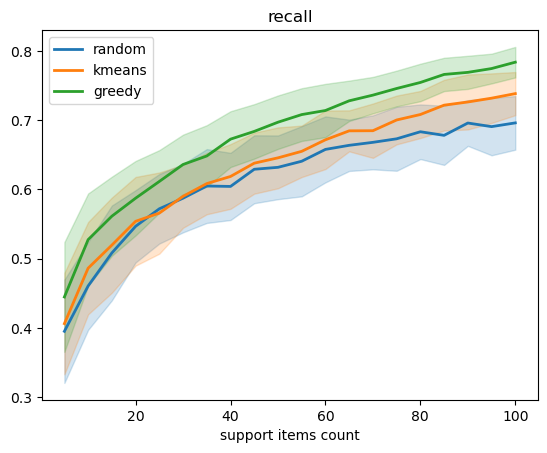

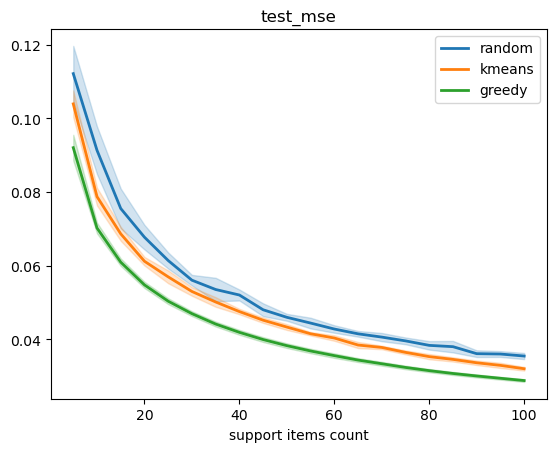

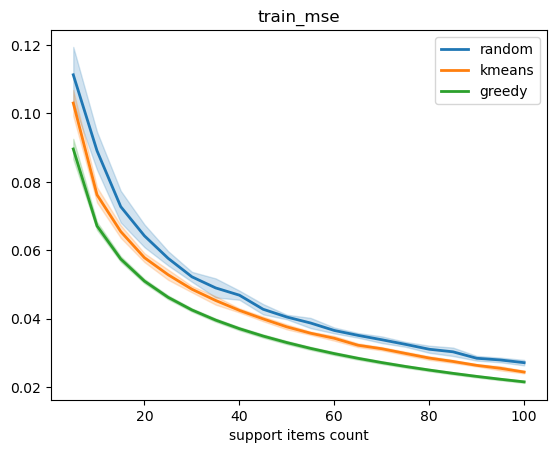

In [27]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for metric in ["recall", "test_mse", "train_mse"]:
    plt.title(metric)
    plt.xlabel("support items count")
    for method, color in zip(methods, colors):
        avg_values = np.array(stats[method][metric]).mean(axis=0)
        stds = np.array(stats[method][metric]).std(axis=0, ddof=1)
        plt.plot(
            item_cnt_range, avg_values, label=method, color=color,
            linewidth=2
        )
        plt.fill_between(item_cnt_range, avg_values - stds, avg_values + stds, color=color, alpha=0.2)
#         for run_values in stats[method][metric]:
#             plt.plot(item_cnt_range, run_values, color=color, linewidth=0.3)
    plt.legend()
    plt.show()


In [29]:
index = item_cnt_range.index(test_item_cnt)
for m in methods:
    recalls = np.array(stats[m]['recall'])[:, index]
    std = recalls.std(ddof=1) / np.sqrt(n_runs)
    print(f"{m:<10} {recalls.mean():<7.3} +- {std:.3f}")

random     0.696   +- 0.012
kmeans     0.738   +- 0.010
greedy     0.784   +- 0.007


In [40]:
for m1, m2 in combinations(methods, 2):
    m1_recalls = np.array(stats[m1]['recall'])[:, index]
    m2_recalls = np.array(stats[m2]['recall'])[:, index]
    ttest_pval = ttest_rel(m1_recalls, m2_recalls).pvalue
    mw_pval = mannwhitneyu(m1_recalls, m2_recalls).pvalue
    print(f"{m1} vs {m2}".ljust(20), f"ttest: {ttest_pval:<10.5f} mann-whitney: {mw_pval:<10.5f}")

random vs kmeans     ttest: 0.00012    mann-whitney: 0.01902   
random vs greedy     ttest: 0.00000    mann-whitney: 0.00024   
kmeans vs greedy     ttest: 0.00005    mann-whitney: 0.00406   
